# Deep Learning Forum 06: Garbage Classification with Vision Transformer (ViT-Large)

This notebook presents an end-to-end pipeline for image-based garbage classification using transfer learning from the pre-trained Hugging Face model `google/vit-large-patch16-224`.

**Primary objectives:**
1. Dataset acquisition from Kaggle with folder-structure-based label assignment,
2. Exploratory data analysis (EDA) covering class distribution and image dimension statistics, with export to an HTML report,
3. Image preprocessing: resize to `224 × 224` via shortest-side scale + centre-crop,
4. Two-stage ViT fine-tuning — frozen backbone (head warm-up) followed by full backbone unfreezing,
5. Periodic checkpointing to prevent loss of training progress,
6. Reflective discussion of three *Food for Thought* questions,
7. Documentation of challenges encountered, solutions applied, conclusions, and recommendations.

**Why Vision Transformer (ViT)?** Unlike conventional convolutional networks, ViT processes an image as a sequence of fixed-size patches and captures long-range spatial dependencies through global self-attention — making it more powerful for distinguishing visually similar material textures such as cardboard versus paper or glass versus plastic.

> **Execution Note:** This notebook is designed for **Google Colab with a GPU runtime** to achieve practical training times. Setup instructions are available in [COLAB_SETUP.md](COLAB_SETUP.md).


In [1]:
from typing import List, Dict

In [2]:
import random
import numpy as np
import tensorflow as tf

# Global reproducibility setup
SEED: int = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Best-effort deterministic ops (not all GPU kernels are deterministic)
try:
    tf.config.experimental.enable_op_determinism()
    print("[SEED] Deterministic TensorFlow ops enabled.")
except Exception as err:
    print(f"[SEED] Deterministic ops could not be fully enabled: {err}")

print(f"[SEED] Global seed configured: {SEED}")


[SEED] Deterministic TensorFlow ops enabled.
[SEED] Global seed configured: 42


In [3]:
# ============================================================
# Install Dependencies (Colab only)
# ============================================================
# This cell installs required packages only when executed
# inside Google Colab; it has no effect on local environments.

import importlib
import subprocess
import sys


def _in_colab() -> bool:
    return "google.colab" in sys.modules or importlib.util.find_spec("google.colab") is not None


if _in_colab():
    packages = [
        "kagglehub",
        "transformers==4.46.3",
        "accelerate",
        "tf-keras",
        "scikit-learn",
        "Pillow",
        "huggingface_hub",
        "matplotlib",
        "seaborn",
        "pandas",
        "jinja2",       # required for HTML report generation
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
    print("Package installation complete.")
    print("NOTE: If this is the first installation or an upgrade, restart the kernel before running ViT training cells.")
else:
    print("Not running on Colab — skipping pip install. Ensure the local virtual environment has all required dependencies.")


Package installation complete.
NOTE: If this is the first installation or an upgrade, restart the kernel before running ViT training cells.


In [4]:
import getpass
import os

# Set to True only when the notebook is executed from the native Colab browser UI.
ENABLE_COLAB_SECRETS: bool = False


def read_token_with_fallback(
        secret_name: str,
        env_name: str,
        prompt_label: str,
        prompt_if_missing: bool = True,
) -> str:
    """Read an API token safely across Colab UI, VS Code, and local notebook runtimes.

    Resolution priority:
        1. OS environment variable  (``env_name``),
        2. Colab Secret             (``secret_name``, only when ``ENABLE_COLAB_SECRETS`` is True),
        3. Interactive prompt       (only when ``prompt_if_missing`` is True).

    Parameters
    ----------
    secret_name : str
        Name of the Colab Secret to query.
    env_name : str
        Name of the OS environment variable to query.
    prompt_label : str
        Human-readable label shown in the interactive prompt.
    prompt_if_missing : bool
        Whether to fall back to an interactive ``getpass`` prompt.

    Returns
    -------
    str
        The resolved token string, or an empty string if unavailable.
    """

    env_value: str = os.getenv(env_name, "").strip()
    if env_value:
        print(f"[TOKEN] {env_name} loaded from environment variable.")
        return env_value

    if ENABLE_COLAB_SECRETS:
        try:
            from google.colab import userdata  # type: ignore
            secret_value: str = (userdata.get(secret_name) or "").strip()
            if secret_value:
                os.environ[env_name] = secret_value
                print(f"[TOKEN] {env_name} loaded from Colab Secret '{secret_name}'.")
                return secret_value
        except Exception as err:
            print(f"[WARN] Failed to read Colab Secret '{secret_name}': {err}")
    else:
        print(
            f"[INFO] Colab Secret '{secret_name}' is skipped because ENABLE_COLAB_SECRETS=False. "
            "The notebook will use an environment variable or an interactive prompt instead."
        )

    if prompt_if_missing:
        prompted_value: str = getpass.getpass(f"Enter {prompt_label}: ").strip()
        if prompted_value:
            os.environ[env_name] = prompted_value
            print(f"[TOKEN] {env_name} loaded from interactive prompt.")
            return prompted_value

    return ""


In [5]:
# Global cell execution logger
# Registers IPython pre/post-run hooks that print a one-line header before each cell
# and a success / failure notice after it completes.
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    if "_step_logger_installed" not in ip.user_ns:
        ip.user_ns["_step_logger_installed"] = False

    if not ip.user_ns["_step_logger_installed"]:
        def _on_pre_run_cell(info):
            raw = (getattr(info, "raw_cell", "") or "").strip().splitlines()
            headline = raw[0] if raw else "<empty cell>"
            print(f"[RUN] {headline[:120]}")

        def _on_post_run_cell(result):
            if result.error_in_exec is None:
                print("[DONE] Cell executed successfully.")
            else:
                print(f"[FAIL] {type(result.error_in_exec).__name__}: {result.error_in_exec}")

        ip.events.register("pre_run_cell", _on_pre_run_cell)
        ip.events.register("post_run_cell", _on_post_run_cell)
        ip.user_ns["_step_logger_installed"] = True
        print("[LOGGER] Global step logger activated for all subsequent cells.")
    else:
        print("[LOGGER] Global step logger already active.")
else:
    print("[LOGGER] IPython runtime not detected — global step logger not installed.")


[LOGGER] Global step logger activated for all subsequent cells.
[DONE] Cell executed successfully.


In [6]:
import os
import kagglehub

# Resolution priority: environment variable → Colab Secret → interactive prompt.
kaggle_token: str = read_token_with_fallback(
    secret_name="KAGGLE_API_TOKEN",
    env_name="KAGGLE_API_TOKEN",
    prompt_label="Kaggle API token",
    prompt_if_missing=True,
)

if kaggle_token:
    os.environ["KAGGLE_API_TOKEN"] = kaggle_token
    print("[KAGGLE] Token configured successfully.")
else:
    print("[KAGGLE] Token not found via environment or secrets. Falling back to interactive kagglehub login...")
    kagglehub.login()
    print("[KAGGLE] Interactive login complete.")


[RUN] import os
[INFO] Colab Secret 'KAGGLE_API_TOKEN' is skipped because ENABLE_COLAB_SECRETS=False. The notebook will use an environment variable or an interactive prompt instead.
[TOKEN] KAGGLE_API_TOKEN loaded from interactive prompt.
[KAGGLE] Token configured successfully.
[DONE] Cell executed successfully.


In [7]:
import tensorflow as tf

# List available hardware
devices: List = tf.config.list_physical_devices()
print(f"Devices found: {devices}")

[RUN] import tensorflow as tf
Devices found: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[DONE] Cell executed successfully.


In [8]:
gpu_devices: List = tf.config.list_physical_devices("GPU")

if gpu_devices:
    print(f"[GPU] Detected {len(gpu_devices)} GPU device(s): {gpu_devices}")
    print("[GPU] Note: GPU availability is independent of Kaggle or Hugging Face authentication status.")

    for each_gpu_device in gpu_devices:
        tf.config.experimental.set_memory_growth(each_gpu_device, True)

    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print(f"[PRECISION] Mixed precision policy activated: {mixed_precision.global_policy()}")
    print("[PRECISION] float16 activations reduce GPU memory consumption by ~50%, enabling larger batch sizes.")
else:
    raise RuntimeError(
        "No GPU detected. Execute this notebook on Google Colab and enable a GPU runtime: "
        "Runtime → Change runtime type → Hardware accelerator → GPU (T4 or A100)."
    )


[RUN] gpu_devices: List = tf.config.list_physical_devices("GPU")
[GPU] Detected 1 GPU device(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[GPU] Note: GPU availability is independent of Kaggle or Hugging Face authentication status.
[PRECISION] Mixed precision policy activated: <DTypePolicy "mixed_float16">
[PRECISION] float16 activations reduce GPU memory consumption by ~50%, enabling larger batch sizes.
[DONE] Cell executed successfully.


## Dataset: Garbage Classification

### Source

| Field | Value |
|---|---|
| **Dataset name** | Garbage Classification |
| **Kaggle handle** | `asdasdasasdas/garbage-classification` |
| **URL** | https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification |
| **Total images** | 2,527 |
| **Image resolution** | 512 × 384 px (uniform across all samples) |

### Class Inventory

The dataset contains **6 garbage categories**, each stored in a dedicated sub-folder:

| ID | Category   | Approx. count |
|----|------------|---------------|
| 0  | cardboard  | 403           |
| 1  | glass      | 501           |
| 2  | metal      | 410           |
| 3  | paper      | 594           |
| 4  | plastic    | 482           |
| 5  | trash      | 137           |

In addition to the images, the archive provides five index text files:
`one-indexed-files-notrash_train.txt`, `one-indexed-files-notrash_val.txt`,  
`one-indexed-files-notrash_test.txt`, `one-indexed-files.txt`, `zero-indexed-files.txt`.

These index files are not used in this notebook; label assignment is derived programmatically from the folder structure instead.

---

### Authentication

Downloading the dataset requires a Kaggle account and an API token. Five authentication methods are supported by the `read_token_with_fallback()` helper defined earlier in this notebook:

---

#### Option 1 — Environment Variable *(recommended for CI / Colab)*

```bash
export KAGGLE_API_TOKEN="<your_token_here>"
```

Set this variable in your shell, `.env` file, or Colab runtime environment before executing the notebook.

---

#### Option 2 — Colab Secret *(recommended for interactive Colab sessions)*

1. Open **Secrets** in the Colab left sidebar (🔑 icon).
2. Add a secret named **`KAGGLE_API_TOKEN`** and paste the token value.
3. Set `ENABLE_COLAB_SECRETS = True` in the token configuration cell above.

> Colab Secrets are encrypted and never exposed in notebook output or version control.

---

#### Option 3 — Interactive Prompt *(fallback for local executions)*

Leave both the environment variable and Colab Secret unset.  
The notebook will present a secure `getpass` prompt at runtime:

```
Enter Kaggle API token: ••••••••••••••••
```

---

#### Option 4 — Legacy API Credentials File

Generate a `kaggle.json` file from your [Kaggle account settings](https://www.kaggle.com/settings) under *Legacy API Credentials → Create Legacy API Key*, then place it at:

- **Linux / macOS:** `~/.kaggle/kaggle.json`
- **Windows:** `%USERPROFILE%\.kaggle\kaggle.json`

Ensure the file permissions are set to `600` on Unix systems.

---

#### Obtaining Your API Token

1. Log in to [kaggle.com](https://www.kaggle.com).
2. Navigate to **Account Settings** → **API** section.
3. Click **"Create New Token"** to download `kaggle.json`.
4. Copy the `key` field value from the downloaded file.


In [9]:
# Authentication confirmation
# The Kaggle token was resolved in the token configuration cell above.
# This cell serves as an explicit checkpoint before proceeding to dataset download.
import kagglehub

print("[AUTH] Kaggle token resolution completed in the token configuration cell.")
print("[AUTH] Proceeding to dataset availability check and download.")


[RUN] # Authentication confirmation
[AUTH] Kaggle token resolution completed in the token configuration cell.
[AUTH] Proceeding to dataset availability check and download.
[DONE] Cell executed successfully.


## Dataset Download — Smart Local Caching

This section implements an idempotent download strategy:

1. **Cache check**: scan the `dataset/` folder for existing `.jpg` or `.txt` files.
2. **Conditional download**: if no files are found, download the dataset from Kaggle via `kagglehub` and copy it to the local `dataset/` directory.
3. **Skip if present**: if files already exist, skip the download and load data directly from disk.

This approach avoids redundant network downloads across repeated notebook executions.


In [10]:
# Download Data Smartly
# If the data is not yet downloaded, we will first download the data from Kaggle to `dataset` folder, and then load them to pandas
# Else, we will load the data from the `dataset` folder directly to pandas

from pathlib import Path
import shutil

import kagglehub

kaggle_dataset_handler_str: str = "asdasdasasdas/garbage-classification"


def resolve_project_root() -> Path:
    """Resolve the project root directory regardless of kernel working directory.

    Walks from the current working directory upward (one level), searching for
    the Forum06 marker files. This ensures the `dataset/` folder is always
    placed inside the actual project root, even when the notebook is launched
    from a different working directory (e.g. Google Colab /content/).
    """
    current_dir = Path.cwd().resolve()
    candidate_dirs = [current_dir, current_dir.parent]
    required_markers = {
        "Forum06-garbage_classification_question.ipynb",
        "Forum06-requirements.txt",
    }

    for each_candidate in candidate_dirs:
        if all((each_candidate / each_marker).exists() for each_marker in required_markers):
            return each_candidate

    # Fallback: use cwd (e.g. on Colab where the notebook lives in /content/)
    return current_dir


project_root: Path = resolve_project_root()
dataset_folder: Path = project_root / "dataset"

dataset_folder.mkdir(parents=True, exist_ok=True)

valid_image_extensions = {".jpg", ".jpeg", ".png"}

available_files = sorted(
    each_found_file.name
    for each_found_file in dataset_folder.glob("**/*")
    if each_found_file.is_file() and each_found_file.suffix.lower() in valid_image_extensions
)

print(f"Project root resolved to : {project_root}")
print(f"Dataset folder resolved to: {dataset_folder}")

if available_files:
    print("Dataset already exists locally. Using files from `dataset/` folder.")
    print(f"Count of available image files: {len(available_files)}")
else:
    downloaded_path_str: str = kagglehub.dataset_download(
        handle=kaggle_dataset_handler_str
    )
    downloaded_path: Path = Path(downloaded_path_str)

    shutil.copytree(
        src=downloaded_path,
        dst=dataset_folder,
        dirs_exist_ok=True,
    )

    available_files = sorted(
        each_found_file.name
        for each_found_file in dataset_folder.glob("**/*")
        if each_found_file.is_file() and each_found_file.suffix.lower() in valid_image_extensions
    )

    print(f"Count of available image files: {len(available_files)}")

[RUN] # Download Data Smartly
Project root resolved to : /content
Dataset folder resolved to: /content/dataset
Dataset already exists locally. Using files from `dataset/` folder.
Count of available image files: 5054
[DONE] Cell executed successfully.


In [11]:
from pathlib import Path

print("Current working directory:", Path.cwd())
print("Resolved dataset folder:", dataset_folder.resolve())
print("Dataset folder exists:", dataset_folder.exists())
print("Sample files:", list(dataset_folder.glob("**/*"))[:10])

[RUN] from pathlib import Path
Current working directory: /content
Resolved dataset folder: /content/dataset
Dataset folder exists: True
Sample files: [PosixPath('/content/dataset/Garbage classification'), PosixPath('/content/dataset/one-indexed-files-notrash_test.txt'), PosixPath('/content/dataset/one-indexed-files-notrash_val.txt'), PosixPath('/content/dataset/one-indexed-files.txt'), PosixPath('/content/dataset/zero-indexed-files.txt'), PosixPath('/content/dataset/garbage classification'), PosixPath('/content/dataset/one-indexed-files-notrash_train.txt'), PosixPath('/content/dataset/Garbage classification/Garbage classification'), PosixPath('/content/dataset/garbage classification/Garbage classification'), PosixPath('/content/dataset/Garbage classification/Garbage classification/plastic')]
[DONE] Cell executed successfully.


## Label Assignment

Each image is assigned a class label based on the name of its immediate parent directory within the dataset folder hierarchy. Label names are then mapped to contiguous integer identifiers to facilitate downstream model training and evaluation.


In [12]:
## Extract category names from the folder structure

from typing import List, Dict
from pprint import pprint

def count_image_files(root_dir: Path) -> int:
    return sum(
        1
        for each_path in root_dir.glob("**/*")
        if each_path.is_file() and each_path.suffix.lower() in valid_image_extensions
    )

def resolve_garbage_classification_root(dataset_folder: Path) -> Path:
    candidate_dirs: List[Path] = sorted(
        each_path
        for each_path in dataset_folder.iterdir()
        if each_path.is_dir() and each_path.name.lower() == "garbage classification"
    )

    if not candidate_dirs:
        raise FileNotFoundError(
            f"No 'Garbage classification' directory was found under {dataset_folder}"
        )

    nested_candidates: List[Path] = []
    for each_dir in candidate_dirs:
        nested_dir = each_dir / "Garbage classification"
        nested_candidates.append(nested_dir if nested_dir.is_dir() else each_dir)

    garbage_root: Path = max(
        nested_candidates,
        key=count_image_files,
    )

    if count_image_files(garbage_root) == 0:
        raise FileNotFoundError(
            f"No image files were found under {garbage_root}"
        )

    return garbage_root

garbage_cls_folder: Path = resolve_garbage_classification_root(dataset_folder)

garbage_cls_names: List[str] = sorted(
    each_folder.name
    for each_folder in garbage_cls_folder.iterdir()
    if each_folder.is_dir() and not each_folder.name.startswith(".")
)

categ_dict: Dict[str, int] = {
    each_cls: each_idx
    for each_idx, each_cls in enumerate(sorted(garbage_cls_names))
}

print(f"Resolved garbage class folder: {garbage_cls_folder}")
pprint(categ_dict, indent=4)

[RUN] ## Extract category names from the folder structure
Resolved garbage class folder: /content/dataset/Garbage classification/Garbage classification
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
[DONE] Cell executed successfully.


In [13]:
## label images
from typing import Union

ClassLabel = List[Dict[str, Union[str, int]]]

def label_images(
        image_paths: List[Path],
        categ_dict: Dict[str, int],
) -> ClassLabel:

    class_labels: ClassLabel = []

    for each_img_path in image_paths:
        label_name: str = each_img_path.parent.name
        categ_int: int = categ_dict[label_name]

        img_label: Dict = {
            "image_path": str(each_img_path)
            , "categ_int": categ_int
        }

        class_labels.append(img_label)

    return class_labels

[RUN] ## label images
[DONE] Cell executed successfully.


In [14]:
garbage_img_paths: List[Path] = sorted(
    each_image_path
    for each_image_path in garbage_cls_folder.glob("**/*")
    if each_image_path.is_file() and each_image_path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

labeled_garbages: ClassLabel = label_images(
    image_paths=garbage_img_paths,
    categ_dict=categ_dict,
)

print(f"Total labeled images: {len(labeled_garbages)}")
print("First 5 labeled records:")
pprint(labeled_garbages[:5], indent=4)


[RUN] garbage_img_paths: List[Path] = sorted(
Total labeled images: 2527
First 5 labeled records:
[   {   'categ_int': 0,
        'image_path': '/content/dataset/Garbage classification/Garbage '
                      'classification/cardboard/cardboard1.jpg'},
    {   'categ_int': 0,
        'image_path': '/content/dataset/Garbage classification/Garbage '
                      'classification/cardboard/cardboard10.jpg'},
    {   'categ_int': 0,
        'image_path': '/content/dataset/Garbage classification/Garbage '
                      'classification/cardboard/cardboard100.jpg'},
    {   'categ_int': 0,
        'image_path': '/content/dataset/Garbage classification/Garbage '
                      'classification/cardboard/cardboard101.jpg'},
    {   'categ_int': 0,
        'image_path': '/content/dataset/Garbage classification/Garbage '
                      'classification/cardboard/cardboard102.jpg'}]
[DONE] Cell executed successfully.


## Exploratory Data Analysis (EDA)

Before partitioning the dataset into training, validation, and test splits, the following exploratory analyses are conducted:

1. **Class distribution**: ensure that each subset will faithfully represent the full dataset, and identify any class imbalance that may inform the training strategy (e.g., class-weighted loss or targeted augmentation).
2. **Image dimension distribution**: verify whether spatial standardisation is required, and quantify the extent of dimensional variability to be addressed during preprocessing.
3. **Per-class visual inspection**: sample images from each category to assess within-class visual diversity and identify potential between-class confusion pairs.
4. **Channel statistics**: compute per-channel mean and standard deviation across the dataset to understand the colour profile of the data.

The EDA results are exported to a standalone HTML report (`EDA_Report_Garbage.html`) at the end of this section.


In [15]:
## Visualize Distribution of Labels

from collections import Counter
from typing import Optional

from matplotlib import pyplot as plt

def viz_label_distribution(
       labeled_garbages: ClassLabel,
       int_to_name: Optional[Dict[int, str]] = None,
) -> Dict[int, int]:

    label_counter: Counter = Counter(
        each_dict["categ_int"]
        for each_dict in labeled_garbages
    )

    label_counts: Dict[int, int] = dict(sorted(label_counter.items()))

    color: Dict[str, str] = {
        "categories" : "#2E86AB"
    }

    fig, ax = plt.subplots(
        figsize=(10, 6),
    )

    x_positions = list(range(len(label_counts)))
    x_labels = (
        [int_to_name.get(k, str(k)) for k in label_counts.keys()]
        if int_to_name
        else [str(k) for k in label_counts.keys()]
    )

    ax.bar(
        x = x_positions
        , height = list(label_counts.values())
        , color = color["categories"]
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=30, ha="right", fontsize=11)

    ax.set_title("Garbage Classification — Label Distribution")
    ax.set_xlabel("Garbage Category")
    ax.set_ylabel("Image Count")

    for pos, val in zip(x_positions, label_counts.values()):
        ax.text(pos, val + 5, str(val), ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()

    return label_counts


[RUN] ## Visualize Distribution of Labels
[DONE] Cell executed successfully.


[RUN] int_to_name: Dict[int, str] = {v: k for k, v in categ_dict.items()}


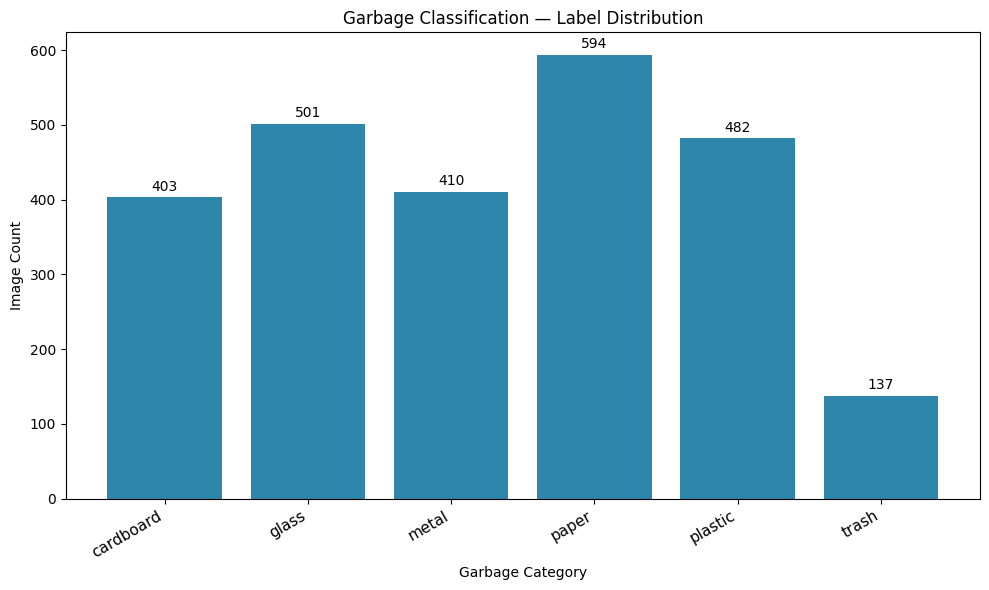

{0: 403, 1: 501, 2: 410, 3: 594, 4: 482, 5: 137}

[DONE] Cell executed successfully.


In [16]:
int_to_name: Dict[int, str] = {v: k for k, v in categ_dict.items()}

label_counts = viz_label_distribution(
    labeled_garbages = labeled_garbages,
    int_to_name = int_to_name,
)

label_counts


The class distribution is notably imbalanced:

| ID | Category   | Image Count | Relative to Mean |
|----|------------|:-----------:|:----------------:|
| 0  | cardboard  | 403         | −16%             |
| 1  | glass      | 501         | +5%              |
| 2  | metal      | 410         | −14%             |
| 3  | paper      | 594         | +24%             |
| 4  | plastic    | 482         | +1%              |
| 5  | **trash**  | **137**     | **−71%**         |

The `trash` category (class ID 5) contains only 137 images — approximately 3.5× fewer than the mean of the remaining five classes (~478 images). Including this severely underrepresented class in model training would introduce significant label bias. Accordingly, **class 5 (`trash`) is excluded from all subsequent modelling steps**.


[RUN] # removing images labeled with class `trash` — the most underrepresented class


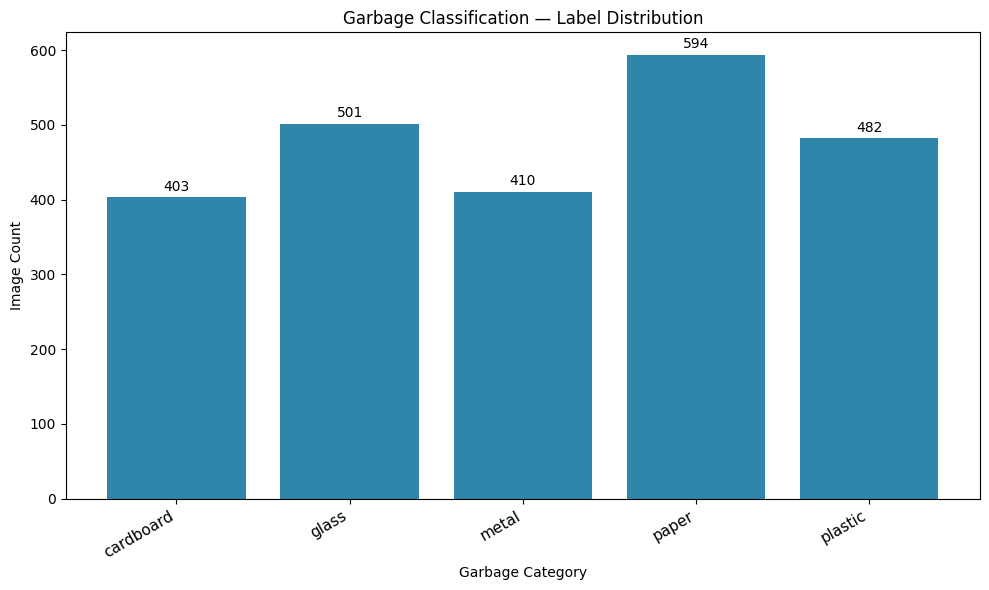

[DONE] Cell executed successfully.


In [17]:
# removing images labeled with class `trash` — the most underrepresented class

if "trash" not in categ_dict:
    raise KeyError("The 'trash' class was not found in categ_dict. Check the resolved dataset folder.")

label_to_remove: int = categ_dict["trash"]
tmp_labeled_garbages: ClassLabel = [
    each_item
    for each_item in labeled_garbages
    if each_item["categ_int"] != label_to_remove
]

updated_label_counts = viz_label_distribution(
    labeled_garbages = tmp_labeled_garbages,
    int_to_name = int_to_name,
)

labeled_garbages = tmp_labeled_garbages.copy() # replace original labeled_garbages with one in which the `trash` label has been removed

In [18]:
## Visualize image size distribution

from collections import Counter
from pathlib import Path
from PIL import Image
import numpy as np

def viz_image_size_distribution(
        labeled_garbages: ClassLabel,
) -> None:

    size_counter: Counter = Counter()
    unreadable_image_paths: List[str] = []

    for each_dict in labeled_garbages:
        each_image_path = Path(each_dict["image_path"])

        try:
            with Image.open(each_image_path) as each_image:
                size_counter[each_image.size] += 1
        except (FileNotFoundError, OSError):
            unreadable_image_paths.append(str(each_image_path))

    if not size_counter:
        raise FileNotFoundError(
            "No readable image files were found in labeled_garbages. Rebuild the dataset paths before rerunning this cell."
        )

    if unreadable_image_paths:
        print(
            f"Skipped {len(unreadable_image_paths)} unreadable image files. Example: {unreadable_image_paths[0]}"
        )

    size_count: Dict = dict(
                            sorted(size_counter.items())
                        )

    color: Dict[str, str] = {
        "categories" : "#2E86AB"
    }

    fig, ax = plt.subplots(
        figsize=(10, 10),
    )

    ax.bar(
        x = str(size_count.keys())
        , height = list(size_count.values())
        , color = color["categories"]
    )

    ax.set_title("Garbage Classification")
    ax.set_xlabel("Image Size")
    ax.set_ylabel("Image Count")

    plt.tight_layout()
    plt.show()

    pprint(size_count, indent=4)

[RUN] ## Visualize image size distribution
[DONE] Cell executed successfully.


[RUN] viz_image_size_distribution(


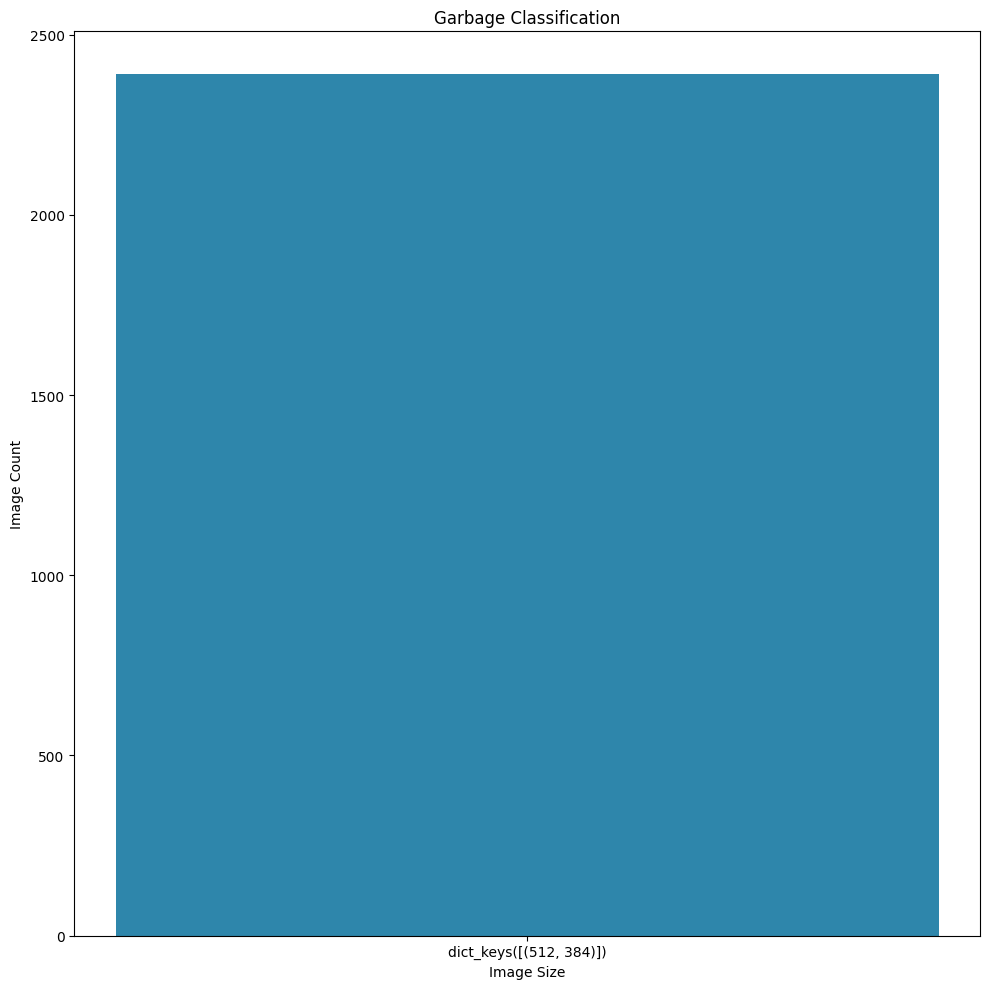

{(512, 384): 2390}
[DONE] Cell executed successfully.


In [19]:
viz_image_size_distribution(
    labeled_garbages = labeled_garbages
)

In [20]:
## Build a comprehensive image metadata DataFrame for EDA

import pandas as pd
from pathlib import Path
from PIL import Image

eda_records = []

for each_item in labeled_garbages:
    img_path: Path = Path(each_item["image_path"])
    categ_id: int = each_item["categ_int"]
    categ_name: str = int_to_name.get(categ_id, str(categ_id))

    try:
        with Image.open(img_path) as img:
            w, h = img.size
            file_size_kb: float = img_path.stat().st_size / 1024
            aspect_ratio: float = round(w / h, 4)

        eda_records.append({
            "file_name"    : img_path.name,
            "category_id"  : categ_id,
            "category"     : categ_name,
            "width_px"     : w,
            "height_px"    : h,
            "file_size_kb" : round(file_size_kb, 2),
            "aspect_ratio" : aspect_ratio,
        })
    except Exception as err:
        print(f"[WARN] Skipped {img_path.name}: {err}")

eda_df: pd.DataFrame = pd.DataFrame(eda_records)

print(f"[EDA] Metadata DataFrame shape : {eda_df.shape}")
print(f"[EDA] Categories represented   : {sorted(eda_df['category'].unique())}")
eda_df.head(10)


[RUN] ## Build a comprehensive image metadata DataFrame for EDA
[EDA] Metadata DataFrame shape : (2390, 7)
[EDA] Categories represented   : ['cardboard', 'glass', 'metal', 'paper', 'plastic']


,file_name,category_id,category,width_px,height_px,file_size_kb,aspect_ratio
0,cardboard1.jpg,0,cardboard,512,384,16.93,1.3333
1,cardboard10.jpg,0,cardboard,512,384,21.17,1.3333
2,cardboard100.jpg,0,cardboard,512,384,14.54,1.3333
3,cardboard101.jpg,0,cardboard,512,384,13.95,1.3333
4,cardboard102.jpg,0,cardboard,512,384,17.59,1.3333
5,cardboard103.jpg,0,cardboard,512,384,20.61,1.3333
6,cardboard104.jpg,0,cardboard,512,384,16.82,1.3333
7,cardboard105.jpg,0,cardboard,512,384,23.84,1.3333
8,cardboard106.jpg,0,cardboard,512,384,25.77,1.3333
9,cardboard107.jpg,0,cardboard,512,384,24.77,1.3333


[DONE] Cell executed successfully.


In [21]:
## EDA — Descriptive statistics per category

print("=" * 60)
print("DESCRIPTIVE STATISTICS — Width (px)")
print("=" * 60)
print(eda_df.groupby("category")["width_px"].describe().to_string())

print()
print("=" * 60)
print("DESCRIPTIVE STATISTICS — Height (px)")
print("=" * 60)
print(eda_df.groupby("category")["height_px"].describe().to_string())

print()
print("=" * 60)
print("DESCRIPTIVE STATISTICS — File Size (KB)")
print("=" * 60)
print(eda_df.groupby("category")["file_size_kb"].describe().round(2).to_string())


[RUN] ## EDA — Descriptive statistics per category
DESCRIPTIVE STATISTICS — Width (px)
           count   mean  std    min    25%    50%    75%    max
category                                                       
cardboard  403.0  512.0  0.0  512.0  512.0  512.0  512.0  512.0
glass      501.0  512.0  0.0  512.0  512.0  512.0  512.0  512.0
metal      410.0  512.0  0.0  512.0  512.0  512.0  512.0  512.0
paper      594.0  512.0  0.0  512.0  512.0  512.0  512.0  512.0
plastic    482.0  512.0  0.0  512.0  512.0  512.0  512.0  512.0

DESCRIPTIVE STATISTICS — Height (px)
           count   mean  std    min    25%    50%    75%    max
category                                                       
cardboard  403.0  384.0  0.0  384.0  384.0  384.0  384.0  384.0
glass      501.0  384.0  0.0  384.0  384.0  384.0  384.0  384.0
metal      410.0  384.0  0.0  384.0  384.0  384.0  384.0  384.0
paper      594.0  384.0  0.0  384.0  384.0  384.0  384.0  384.0
plastic    482.0  384.0  0.0  384.0  384.0 

[RUN] ## EDA — File size and aspect ratio distribution per category


/tmp/ipykernel_42695/3980583215.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_42695/3980583215.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


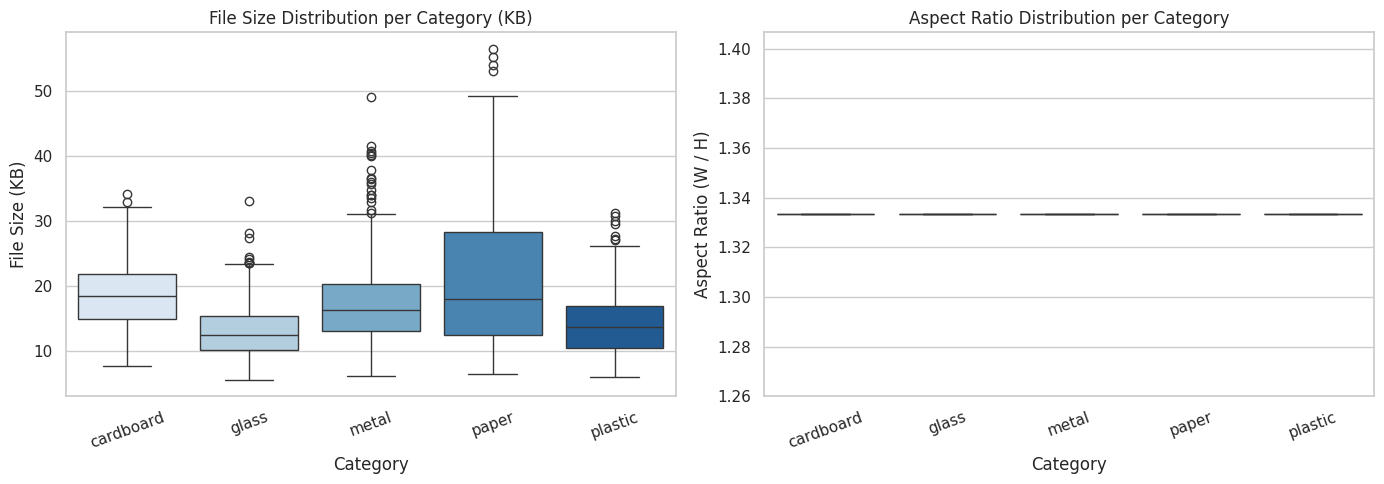


Global aspect ratio — mean: 1.3333, std: 0.0000
[DONE] Cell executed successfully.


In [22]:
## EDA — File size and aspect ratio distribution per category

import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# File size distribution
sns.boxplot(
    data=eda_df, x="category", y="file_size_kb",
    palette="Blues", ax=axes[0]
)
axes[0].set_title("File Size Distribution per Category (KB)")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("File Size (KB)")
axes[0].tick_params(axis="x", rotation=20)

# Aspect ratio distribution
sns.boxplot(
    data=eda_df, x="category", y="aspect_ratio",
    palette="Blues", ax=axes[1]
)
axes[1].set_title("Aspect Ratio Distribution per Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Aspect Ratio (W / H)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print(f"\nGlobal aspect ratio — mean: {eda_df['aspect_ratio'].mean():.4f}, std: {eda_df['aspect_ratio'].std():.4f}")


[RUN] ## EDA — Per-category sample grid (3 random images per class)


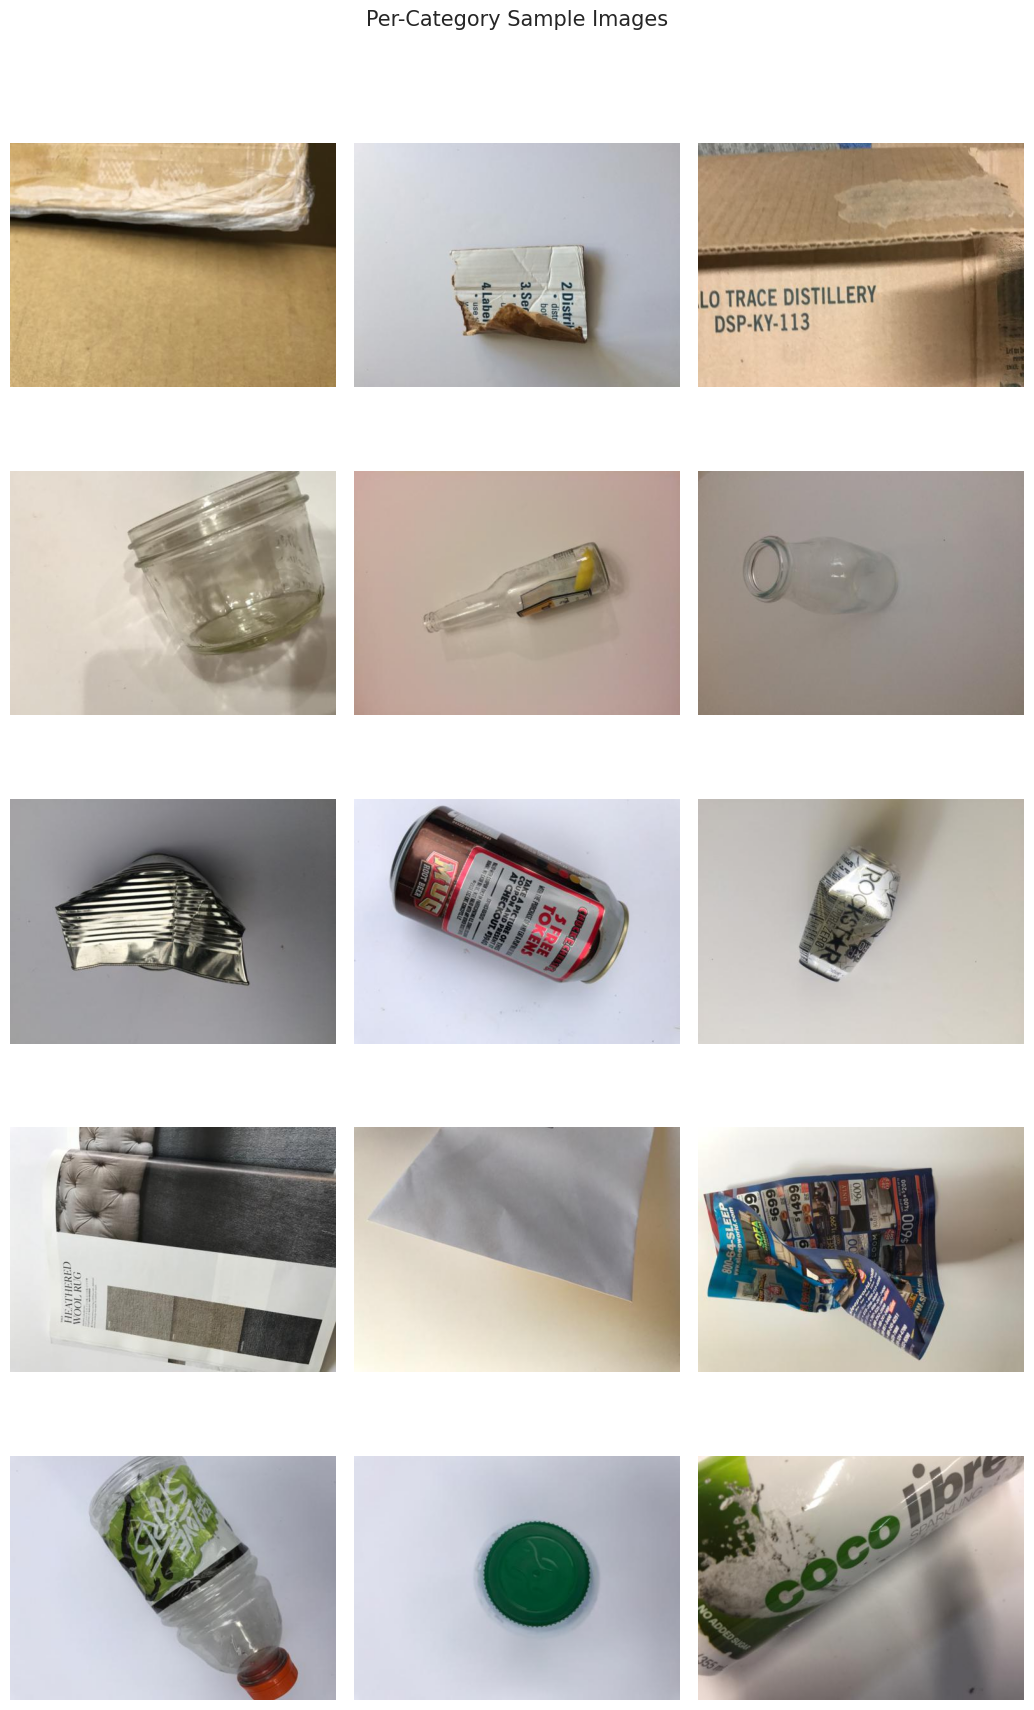

[DONE] Cell executed successfully.


In [23]:
## EDA — Per-category sample grid (3 random images per class)

import random

random.seed(42)
SAMPLES_PER_CLASS: int = 3
categories_present = sorted(eda_df["category"].unique())

fig, axes = plt.subplots(
    len(categories_present), SAMPLES_PER_CLASS,
    figsize=(SAMPLES_PER_CLASS * 3.5, len(categories_present) * 3.5),
)

for row_idx, category in enumerate(categories_present):
    category_paths = eda_df.loc[eda_df["category"] == category, "file_name"].tolist()
    # Locate full paths from original labeled_garbages
    full_paths = [
        item["image_path"]
        for item in labeled_garbages
        if Path(item["image_path"]).name in category_paths
    ]
    sampled_paths = random.sample(full_paths, min(SAMPLES_PER_CLASS, len(full_paths)))

    for col_idx in range(SAMPLES_PER_CLASS):
        ax = axes[row_idx][col_idx]
        if col_idx < len(sampled_paths):
            with Image.open(sampled_paths[col_idx]) as img:
                ax.imshow(img)
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(category, fontsize=13, labelpad=8, rotation=0, ha="right", va="center")

fig.suptitle("Per-Category Sample Images", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


[RUN] ## EDA — Per-channel pixel statistics (sampled subset for performance)


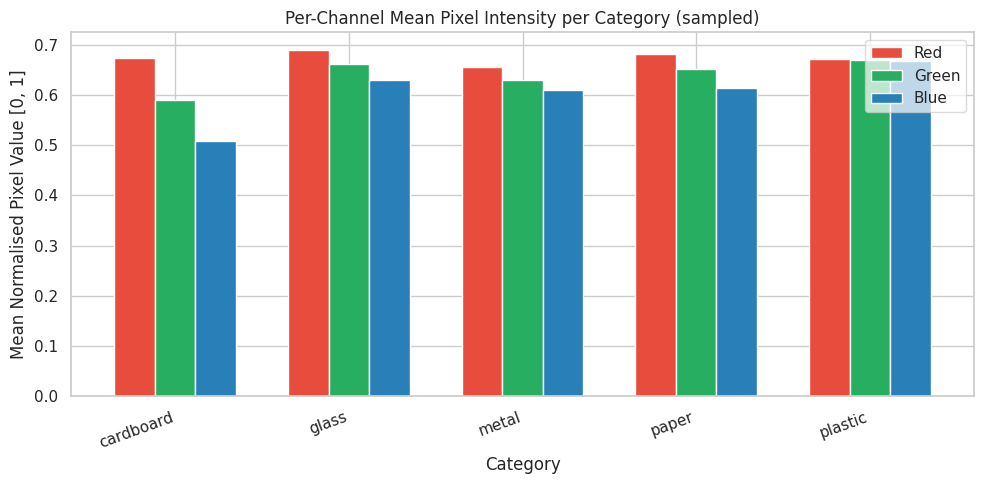


Channel Statistics Table:
           mean_R  mean_G  mean_B   std_R   std_G   std_B
category                                                 
cardboard  0.6724  0.5893  0.5074  0.0792  0.0884  0.1228
glass      0.6898  0.6621  0.6299  0.0569  0.0561  0.0802
metal      0.6562  0.6295  0.6087  0.0995  0.0952  0.1105
paper      0.6807  0.6523  0.6145  0.0759  0.0727  0.0752
plastic    0.6718  0.6691  0.6676  0.0534  0.0556  0.0840
[DONE] Cell executed successfully.


In [24]:
## EDA — Per-channel pixel statistics (sampled subset for performance)

import numpy as np

CHANNEL_SAMPLE_SIZE: int = 200   # images sampled per class for channel stats
channel_records = []

for category in categories_present:
    cat_items = [
        item for item in labeled_garbages
        if int_to_name.get(item["categ_int"]) == category
    ]
    sampled = random.sample(cat_items, min(CHANNEL_SAMPLE_SIZE, len(cat_items)))

    r_vals, g_vals, b_vals = [], [], []
    for item in sampled:
        try:
            with Image.open(item["image_path"]) as img:
                arr = np.array(img.convert("RGB"), dtype=np.float32) / 255.0
                r_vals.append(arr[:, :, 0].mean())
                g_vals.append(arr[:, :, 1].mean())
                b_vals.append(arr[:, :, 2].mean())
        except Exception:
            continue

    channel_records.append({
        "category"   : category,
        "mean_R"     : round(float(np.mean(r_vals)), 4),
        "mean_G"     : round(float(np.mean(g_vals)), 4),
        "mean_B"     : round(float(np.mean(b_vals)), 4),
        "std_R"      : round(float(np.std(r_vals)), 4),
        "std_G"      : round(float(np.std(g_vals)), 4),
        "std_B"      : round(float(np.std(b_vals)), 4),
    })

channel_df = pd.DataFrame(channel_records).set_index("category")

# Visualise channel means as grouped bars
channel_means = channel_df[["mean_R", "mean_G", "mean_B"]]
channel_means.plot(
    kind="bar",
    color=["#E74C3C", "#27AE60", "#2980B9"],
    figsize=(10, 5),
    width=0.7,
    edgecolor="white",
)
plt.title("Per-Channel Mean Pixel Intensity per Category (sampled)")
plt.xlabel("Category")
plt.ylabel("Mean Normalised Pixel Value [0, 1]")
plt.xticks(rotation=20, ha="right")
plt.legend(["Red", "Green", "Blue"], framealpha=0.7)
plt.tight_layout()
plt.show()

print("\nChannel Statistics Table:")
print(channel_df.to_string())


In [25]:
## EDA — Generate HTML report

import base64
import io
import textwrap
from pathlib import Path

def fig_to_base64(fig: plt.Figure) -> str:
    """Render a Matplotlib figure to a base64-encoded PNG string."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

# ── Figure 1: label distribution ──────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 5))
x_pos = list(range(len(label_counts)))
ax1.bar(x_pos, list(label_counts.values()), color="#2E86AB")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(
    [int_to_name.get(k, str(k)) for k in label_counts.keys()],
    rotation=20, ha="right",
)
ax1.set_title("Full Dataset — Label Distribution (6 Classes)")
ax1.set_xlabel("Category")
ax1.set_ylabel("Image Count")
for pos, val in zip(x_pos, label_counts.values()):
    ax1.text(pos, val + 5, str(val), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
fig1_b64 = fig_to_base64(fig1)
plt.close(fig1)

# ── Figure 2: label distribution after dropping trash ─────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))
filtered_counts = {k: v for k, v in label_counts.items() if k != 5}
x_pos2 = list(range(len(filtered_counts)))
ax2.bar(x_pos2, list(filtered_counts.values()), color="#27AE60")
ax2.set_xticks(x_pos2)
ax2.set_xticklabels(
    [int_to_name.get(k, str(k)) for k in filtered_counts.keys()],
    rotation=20, ha="right",
)
ax2.set_title("Modelling Dataset — Label Distribution (5 Classes, trash excluded)")
ax2.set_xlabel("Category")
ax2.set_ylabel("Image Count")
for pos, val in zip(x_pos2, filtered_counts.values()):
    ax2.text(pos, val + 5, str(val), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
fig2_b64 = fig_to_base64(fig2)
plt.close(fig2)

# ── Figure 3: file size boxplot ────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(10, 5))
sns.boxplot(data=eda_df, x="category", y="file_size_kb", palette="Blues", ax=ax3)
ax3.set_title("File Size Distribution per Category (KB)")
ax3.set_xlabel("Category")
ax3.set_ylabel("File Size (KB)")
ax3.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig3_b64 = fig_to_base64(fig3)
plt.close(fig3)

# ── Figure 4: channel means bar chart ─────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(10, 5))
channel_means.plot(
    kind="bar",
    color=["#E74C3C", "#27AE60", "#2980B9"],
    ax=ax4, width=0.7, edgecolor="white",
)
ax4.set_title("Per-Channel Mean Pixel Intensity per Category (sampled)")
ax4.set_xlabel("Category")
ax4.set_ylabel("Mean Normalised Pixel Value [0, 1]")
ax4.tick_params(axis="x", rotation=20)
ax4.legend(["Red", "Green", "Blue"], framealpha=0.7)
plt.tight_layout()
fig4_b64 = fig_to_base64(fig4)
plt.close(fig4)

# ── HTML template ──────────────────────────────────────────────────────
html_stats_table = eda_df.groupby("category").agg(
    count=("file_name", "count"),
    mean_W=("width_px", "mean"),
    mean_H=("height_px", "mean"),
    mean_size_kb=("file_size_kb", "mean"),
    mean_aspect=("aspect_ratio", "mean"),
).round(2).reset_index().to_html(index=False, border=0, classes="stats-table")

channel_html = channel_df.round(4).to_html(border=0, classes="stats-table")

html_report = textwrap.dedent(f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>EDA Report — Garbage Classification Dataset</title>
<style>
  body {{font-family: 'Segoe UI', Arial, sans-serif; background:#f7f9fc; color:#2c3e50; margin:0; padding:0;}}
  header {{background:#2E86AB; color:white; padding:2rem 3rem;}}
  header h1 {{margin:0; font-size:1.8rem;}}
  header p {{margin:0.3rem 0 0; opacity:0.85; font-size:0.95rem;}}
  main {{max-width:1100px; margin:2rem auto; padding:0 2rem;}}
  h2 {{border-left:5px solid #2E86AB; padding-left:0.8rem; margin-top:2.5rem; color:#1a252f;}}
  h3 {{color:#2E86AB; margin-top:1.5rem;}}
  img {{max-width:100%; border-radius:6px; box-shadow:0 2px 8px rgba(0,0,0,0.12); margin:1rem 0;}}
  .stats-table {{border-collapse:collapse; width:100%; font-size:0.9rem;}}
  .stats-table th {{background:#2E86AB; color:white; padding:0.6rem 0.9rem; text-align:left;}}
  .stats-table td {{padding:0.5rem 0.9rem; border-bottom:1px solid #dce3ea;}}
  .stats-table tr:nth-child(even) td {{background:#eaf3fb;}}
  .summary-grid {{display:grid; grid-template-columns:repeat(auto-fit, minmax(180px,1fr)); gap:1rem; margin:1.5rem 0;}}
  .card {{background:white; border-radius:8px; padding:1.2rem; box-shadow:0 1px 6px rgba(0,0,0,0.08); text-align:center;}}
  .card .value {{font-size:2rem; font-weight:700; color:#2E86AB;}}
  .card .label {{font-size:0.85rem; color:#7f8c8d; margin-top:0.3rem;}}
  footer {{text-align:center; padding:2rem; color:#7f8c8d; font-size:0.85rem;}}
</style>
</head>
<body>
<header>
  <h1>EDA Report — Garbage Classification Dataset</h1>
  <p>Forum 06 | Deep Learning | google/vit-large-patch16-224</p>
</header>
<main>

<h2>1. Dataset Overview</h2>
<div class="summary-grid">
  <div class="card"><div class="value">2,527</div><div class="label">Total images (raw)</div></div>
  <div class="card"><div class="value">6</div><div class="label">Original categories</div></div>
  <div class="card"><div class="value">2,390</div><div class="label">Images after removing <em>trash</em></div></div>
  <div class="card"><div class="value">5</div><div class="label">Categories used for modelling</div></div>
  <div class="card"><div class="value">512&nbsp;×&nbsp;384</div><div class="label">Uniform source resolution (px)</div></div>
</div>

<h2>2. Class Distribution — Full Dataset</h2>
<img src="data:image/png;base64,{fig1_b64}" alt="Label distribution — all 6 classes">

<h2>3. Class Distribution — Modelling Dataset (trash excluded)</h2>
<img src="data:image/png;base64,{fig2_b64}" alt="Label distribution — 5 classes">

<h2>4. Per-Category Descriptive Statistics</h2>
{html_stats_table}

<h2>5. File Size Distribution per Category</h2>
<img src="data:image/png;base64,{fig3_b64}" alt="File size boxplot">

<h2>6. Per-Channel Pixel Statistics</h2>
<img src="data:image/png;base64,{fig4_b64}" alt="Channel mean bar chart">
{channel_html}

<h2>7. Key Observations</h2>
<ul>
  <li><strong>Class imbalance:</strong> The <em>trash</em> category is severely underrepresented (137 images vs. a mean of ~478 for the remaining five classes). It is excluded from modelling to prevent label bias.</li>
  <li><strong>Uniform image dimensions:</strong> All images share a resolution of 512 × 384 px, simplifying the preprocessing pipeline.</li>
  <li><strong>Visual similarity risk:</strong> The <em>cardboard</em> and <em>paper</em> categories show relatively close RGB channel-intensity tendencies in sampled EDA statistics, making this pair a plausible confusion risk.</li>
  <li><strong>Glass distinctiveness:</strong> The <em>glass</em> category shows comparatively lower channel-intensity means, consistent with the transparent and reflective nature of many glass objects.</li>
</ul>

</main>
<footer>Generated automatically by Forum06-garbage_classification_question.ipynb</footer>
</body>
</html>
""").strip()

# ── Write report to disk ───────────────────────────────────────────────
eda_report_path: Path = project_root / "EDA_Report_Garbage.html"
eda_report_path.write_text(html_report, encoding="utf-8")
print(f"[EDA] HTML report written to: {eda_report_path.resolve()}")
print(f"[EDA] Report file size      : {eda_report_path.stat().st_size / 1024:.1f} KB")


[RUN] ## EDA — Generate HTML report


/tmp/ipykernel_42695/3094667828.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x="category", y="file_size_kb", palette="Blues", ax=ax3)


[EDA] HTML report written to: /content/EDA_Report_Garbage.html
[EDA] Report file size      : 198.1 KB
[DONE] Cell executed successfully.


In [26]:
## EDA — Export a standalone EDA notebook (EDA_Report_Garbage.ipynb)

import json
from copy import deepcopy

# This exporter builds a compact, standalone EDA notebook so the analysis can be
# reviewed independently from the full training notebook.

eda_notebook_cells = [
    {
        "cell_type": "markdown",
        "metadata": {},
        "source": [
            "# EDA Report: Garbage Classification Dataset\n",
            "\n",
            "This standalone report notebook contains the exploratory analysis used in Forum 06, including class distribution, image geometry, file-size statistics, channel summaries, and key findings.\n",
        ],
    },
    {
        "cell_type": "markdown",
        "metadata": {},
        "source": [
            "## Dataset Summary\n",
            "- Source: Kaggle (`asdasdasasdas/garbage-classification`)\n",
            "- Raw size: 2,527 images, 6 categories\n",
            "- Modelling subset: 2,390 images, 5 categories (`trash` excluded)\n",
            "- Native resolution: 512 × 384 px\n",
        ],
    },
    {
        "cell_type": "code",
        "metadata": {},
        "execution_count": None,
        "outputs": [],
        "source": [
            "import pandas as pd\n",
            "from pathlib import Path\n",
            "\n",
            "project_root = Path.cwd().expanduser()\n",
            "dataset_folder = project_root / 'dataset' / 'Garbage classification' / 'Garbage classification'\n",
            "\n",
            "records = []\n",
            "for category_dir in sorted([p for p in dataset_folder.iterdir() if p.is_dir()]):\n",
            "    for img_path in category_dir.glob('**/*'):\n",
            "        if img_path.is_file() and img_path.suffix.lower() in {'.jpg', '.jpeg', '.png'}:\n",
            "            records.append({'category': category_dir.name, 'image_path': str(img_path)})\n",
            "\n",
            "eda_df = pd.DataFrame(records)\n",
            "print('EDA DataFrame shape:', eda_df.shape)\n",
            "eda_df.head()\n",
        ],
    },
    {
        "cell_type": "markdown",
        "metadata": {},
        "source": [
            "## Key Findings\n",
            "1. The `trash` class is severely underrepresented and is therefore excluded from modelling.\n",
            "2. All images share the same spatial resolution, simplifying preprocessing.\n",
            "3. A likely confusion pair is cardboard vs. paper due to similar appearance and texture cues; this remains a hypothesis to validate quantitatively.\n",
        ],
    },
    {
        "cell_type": "markdown",
        "metadata": {},
        "source": [
            "## Notes\n",
            "For the full visual analysis (plots and HTML export), refer to `Forum06-garbage_classification_question.ipynb` and `EDA_Report_Garbage.html`.\n",
        ],
    },
]

eda_notebook = {
    "cells": eda_notebook_cells,
    "metadata": {
        "kernelspec": {
            "display_name": "Python 3",
            "language": "python",
            "name": "python3",
        },
        "language_info": {
            "name": "python",
            "version": "3.10",
        },
    },
    "nbformat": 4,
    "nbformat_minor": 5,
}

eda_notebook_path: Path = project_root / "EDA_Report_Garbage.ipynb"
eda_notebook_path.write_text(json.dumps(eda_notebook, indent=2), encoding="utf-8")

print(f"[EDA] Standalone notebook written to: {eda_notebook_path.resolve()}")


[RUN] ## EDA — Export a standalone EDA notebook (EDA_Report_Garbage.ipynb)
[EDA] Standalone notebook written to: /content/EDA_Report_Garbage.ipynb
[DONE] Cell executed successfully.


All images in the dataset share a uniform spatial resolution of **(384 × 512) pixels** (width × height).

This homogeneity is an advantageous property compared to datasets with variable dimensions, as it:
- eliminates the need for per-image padding or selective scaling,
- ensures the resize transformation is deterministic and reproducible,
- prevents asymmetric distortion artefacts during preprocessing.

Despite the uniform source resolution, a resize step to **224 × 224** remains necessary to match the required input dimensions of `google/vit-large-patch16-224`.


## Image Preprocessing — Resize to 224 × 224

All images are resized from their native resolution of `(384 × 512)` pixels to `(224, 224, 3)` prior to model input. The target resolution of **224 × 224** is selected for the following reasons:

1. **ViT-Large compatibility**: `google/vit-large-patch16-224` partitions each image into non-overlapping 16 × 16 px patches, yielding $\dfrac{224}{16} \times \dfrac{224}{16} = 14 \times 14 = 196$ sequence tokens. Deviating from the pre-training resolution would require re-learning positional embeddings from scratch.
2. **ImageNet convention**: 224 × 224 is the de-facto standard for ImageNet pre-trained models (ResNet, VGG, EfficientNet, ViT). Using this resolution ensures fair cross-architecture comparisons.
3. **GPU memory efficiency**: compared to a 384 × 384 variant (ViT-Large/384), the 224 × 224 resolution reduces the activation tensor size by ~2.9×, which is critical when operating under the 16 GB memory constraint of a T4 GPU.

The resize is performed in two stages:
1. **Shortest-side upscale**: scale the image so its shortest dimension equals 224 px while preserving the original aspect ratio (LANCZOS resampling to minimise aliasing artefacts).
2. **Centre crop**: extract a 224 × 224 square from the geometrical centre of the scaled image.


In [27]:
## Define function to resize the smallest dimension to 224 pixel

from PIL import Image
import numpy as np

def resize_shortest(
        img: Image.Image
) -> np.ndarray:

    """Resize an image so its shortest side becomes 224 pixels.

    This function converts the input image to RGB mode, computes a scale
    factor from the shortest spatial dimension, and resizes the image while
    preserving its aspect ratio. The resized image is returned as a NumPy
    array with three RGB channels.

    Parameters
    ----------
    img : PIL.Image.Image
        Input image to be resized.
        Default value: no default value.

    Returns
    -------
    np.ndarray
        Resized RGB image as a NumPy array with shape `(height, width, 3)`.
    """

    TARGET_SIZE: int = 224

    # Ensure the image is in RGB format
    rgb_image: Image.Image = img.convert("RGB")

    scale_factor: float = TARGET_SIZE / min(rgb_image.height, rgb_image.width)
    new_w: int = round(rgb_image.width * scale_factor)
    new_h: int = round(rgb_image.height * scale_factor)

    resized_image: Image.Image = rgb_image.resize(
        size = (new_w, new_h)
        , resample = Image.Resampling.LANCZOS
    )

    scaled_image_np: np.ndarray = np.array(resized_image)

    return scaled_image_np

[RUN] ## Define function to resize the smallest dimension to 224 pixel
[DONE] Cell executed successfully.


In [28]:
# Define function to crop image from the center
def crop_from_center(
        img: np.ndarray
) -> np.ndarray:

    """Crop the center region of an image to 224 x 224 pixels.

    This function extracts a square crop from the center of a NumPy image
    array. It assumes the input image has already been resized so that both
    spatial dimensions are at least 224 pixels. The output preserves the
    original channel dimension and returns the centered crop as a NumPy
    array.

    Parameters
    ----------
    img : np.ndarray
        Input image as a NumPy array with shape `(height, width, channels)`.
        Default value: no default value.

    Returns
    -------
    np.ndarray
        Center-cropped image as a NumPy array with shape `(224, 224, channels)`.
    """

    TARGET_SIZE: int = 224

    image_h: int = img.shape[0]
    image_w: int = img.shape[1]

    if image_h < TARGET_SIZE or image_w < TARGET_SIZE:
        raise ValueError("Input image must be at least 224x224 before center cropping.")

    left_pt: int = (image_w - TARGET_SIZE) // 2
    right_pt: int = left_pt + TARGET_SIZE

    top_pt: int = (image_h - TARGET_SIZE) // 2
    bottom_pt: int = top_pt + TARGET_SIZE

    cropped_image_np: np.ndarray = img[top_pt:bottom_pt, left_pt:right_pt, :]

    return cropped_image_np

[RUN] # Define function to crop image from the center
[DONE] Cell executed successfully.


In [29]:
def resize_and_crop_image(
        img: Image.Image
)-> np.ndarray:

    """Resize and Crop Image to (224, 224, 3) size

    This function takes an image as input and perform the following steps:
    1. Resize the image to (height, 224) or (224, height) using the resize_shortest function
    2. Crop the resized image to (224, 224, 3) using the crop_from_center function

    Parameters
    ---------
    :param img: PIL.Image.Image
        PIL Image object  to be resized and cropped
        Default value: no default value.

    Returns
    :return: np.ndarray
        Resized and Cropped Image as a NumPy array with shape (224, 224, 3)
    """

    resized_img: np.ndarray = resize_shortest(img = img)
    cropped_img: np.ndarray = crop_from_center(img = resized_img)

    return cropped_img

[RUN] def resize_and_crop_image(
[DONE] Cell executed successfully.


[RUN] # Test the resize-and-crop utiliy function
Original Image Size: (512, 384)


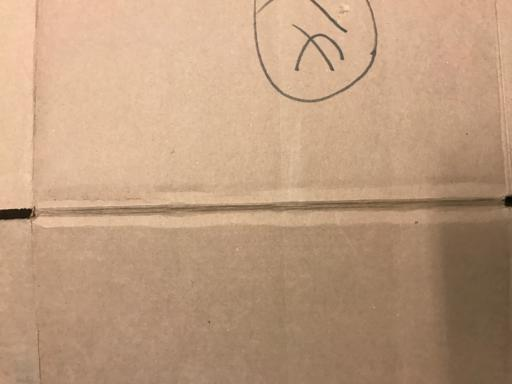

[DONE] Cell executed successfully.


In [30]:
# Test the resize-and-crop utiliy function

test_image_dict: Dict[str, Union[str, Path]] = labeled_garbages[0]
test_image_path: Path = test_image_dict["image_path"]
test_image: Image.Image = Image.open(test_image_path)

print(f"Original Image Size: {test_image.size}")
display(test_image)

[RUN] from matplotlib import pyplot as plt
Resized and Cropped Image Size: (224, 224, 3)


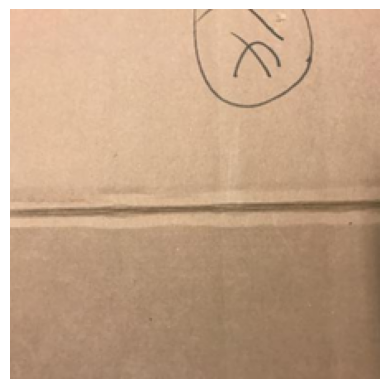

[DONE] Cell executed successfully.


In [31]:
from matplotlib import pyplot as plt
import numpy as np

prc_img: np.ndarray = resize_and_crop_image(img = test_image)

print(f"Resized and Cropped Image Size: {prc_img.shape}")
plt.imshow(prc_img)
plt.axis("off")
plt.show()

## 🧠 Food For Thought

The notebook resizes all images to 224 x 224 to match the pretrained ViT input. What information might be lost from the original images during this resizing step, and how could that affect classification performance for small or fine-grained garbage objects?

### Discussion - Information Loss from Resizing to 224 x 224

The source images have a resolution of **384 x 512 pixels**. The two-stage transform (shortest-side resize + center crop to 224 x 224) introduces two primary information-loss mechanisms:

#### 1. Spatial Resolution Reduction (Downscaling)
Compressing a 512-pixel dimension to 224 pixels removes fine-grained visual details that may be class-discriminative in this domain:
- **Surface texture** - cardboard fibers, glass reflections, metallic scratches,
- **Structural edges** - paper folds, plastic indentations, corrugated board fluting,
- **Small-scale patterns** - product labels, material degradation marks.

For objects such as crumpled metal foil or transparent plastic film, these micro-features can be critical cues; aggressive downscaling may weaken their visibility.

#### 2. Context Truncation from Center Cropping
The center-crop step discards border regions of the resized frame:
- Off-center objects may be **partially or fully excluded**,
- Potentially relevant background context is removed,
- Distinctive object parts (for example bottle necks or cardboard flaps) may be lost.

#### 3. Impact on Classification Performance
Based on EDA channel statistics and qualitative inspection, **cardboard vs. paper** and **plastic vs. glass** emerge as plausible confusion pairs. Cardboard and paper share relatively similar color-intensity tendencies and flat geometry, while plastic and glass can overlap visually when transparent containers are photographed against bright backgrounds.

In the stored prediction examples in this notebook, one **paper** sample is classified as **cardboard** with confidence **0.68**. The same preview also shows multiple **plastic** samples classified as **glass** with confidences such as **0.66**, **0.90**, and **0.31**. These examples support the hypothesis that resizing and cropping can suppress subtle texture or material cues, but they remain qualitative evidence only; a confusion matrix on the full test split would still be the stronger basis for final claims.

#### 4. Mitigation Strategies
| Strategy | Description |
|---|---|
| **Random crop during training** | Randomize crop location instead of always using center crop to expose varied spatial context |
| **Multi-scale augmentation** | Train with varied resize scales to improve scale robustness |
| **Patch-based ensemble inference** | Predict from multiple crops and aggregate probabilities |
| **Higher-resolution ViT variant** | Use `google/vit-large-patch16-384` to preserve more detail, with substantially higher memory/compute cost |

Having defined the `resize_and_crop_image` utility, the next step is to build the TensorFlow `Dataset` preprocessing pipeline that wraps this function for efficient batched loading during training and inference.


In [32]:
from typing import Tuple, List, Dict, Union
from pathlib import Path

import numpy as np
import tensorflow as tf
from PIL import Image

[RUN] from typing import Tuple, List, Dict, Union
[DONE] Cell executed successfully.


In [33]:
def prepare_records(
        labeled_images: ClassLabel
) -> Tuple[List[str], List[int]]:

     image_paths: List[str] = [
         str(each_item["image_path"]) for each_item in labeled_images
     ]

     labels_int: List[int] = [
        each_item["categ_int"] for each_item in labeled_images
     ]

     return image_paths, labels_int

[RUN] def prepare_records(
[DONE] Cell executed successfully.


In [34]:
image_paths, categ_int = prepare_records(labeled_images=labeled_garbages)

print("Sample image paths:")
print(image_paths[:3])
print("\nSample category integers:")
print(categ_int[:3])


[RUN] image_paths, categ_int = prepare_records(labeled_images=labeled_garbages)
Sample image paths:
['/content/dataset/Garbage classification/Garbage classification/cardboard/cardboard1.jpg', '/content/dataset/Garbage classification/Garbage classification/cardboard/cardboard10.jpg', '/content/dataset/Garbage classification/Garbage classification/cardboard/cardboard100.jpg']

Sample category integers:
[0, 0, 0]
[DONE] Cell executed successfully.


In [35]:
# Prepare train : validation : test data split

from collections import Counter
from sklearn.model_selection import train_test_split

# 70% train, 15% validation, 15% test with stratified sampling
train_paths, tmp_paths, train_ctg, tmp_ctg = train_test_split(
    image_paths,
    categ_int,
    test_size = 0.30,
    random_state = 42,
    stratify = categ_int,
)

val_paths, test_paths, val_ctg, test_ctg = train_test_split(
    tmp_paths,
    tmp_ctg,
    test_size = 0.50,
    random_state = 42,
    stratify = tmp_ctg,
)

print("[SPLIT SUMMARY]")
print(f"Train size      : {len(train_paths)}")
print(f"Validation size : {len(val_paths)}")
print(f"Test size       : {len(test_paths)}")
print(f"Total samples   : {len(train_paths) + len(val_paths) + len(test_paths)}")

train_dist = dict(sorted(Counter(train_ctg).items()))
val_dist = dict(sorted(Counter(val_ctg).items()))
test_dist = dict(sorted(Counter(test_ctg).items()))

print("[CLASS DISTRIBUTION]")
print(f"Train      : {train_dist}")
print(f"Validation : {val_dist}")
print(f"Test       : {test_dist}")

[RUN] # Prepare train : validation : test data split
[SPLIT SUMMARY]
Train size      : 1673
Validation size : 358
Test size       : 359
Total samples   : 2390
[CLASS DISTRIBUTION]
Train      : {0: 282, 1: 351, 2: 287, 3: 416, 4: 337}
Validation : {0: 61, 1: 75, 2: 61, 3: 89, 4: 72}
Test       : {0: 60, 1: 75, 2: 62, 3: 89, 4: 73}
[DONE] Cell executed successfully.


[RUN] # Check distribution of categories in train, validation, and test datasets


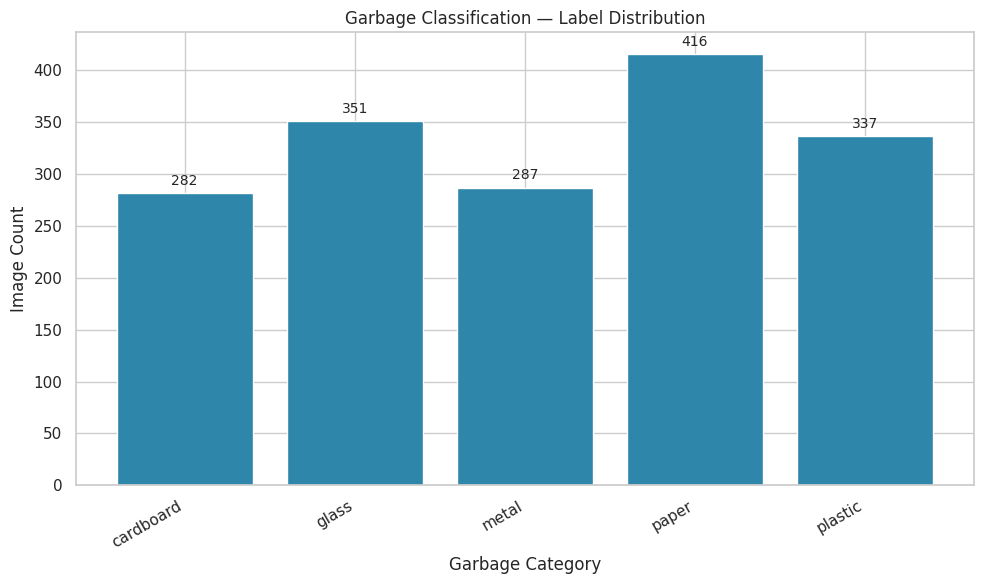

{0: 282, 1: 351, 2: 287, 3: 416, 4: 337}

[DONE] Cell executed successfully.


In [36]:
# Check distribution of categories in train, validation, and test datasets

# Category Distribution in Train Dataset
train_labeled_garbage: ClassLabel = [
        {"image_path" : each_path, "categ_int" : each_ctg}
        for each_path, each_ctg in zip(train_paths, train_ctg)
    ]

viz_label_distribution(
    labeled_garbages = train_labeled_garbage,
    int_to_name = int_to_name,
)


[RUN] # Category Distribution in Validation Dataset


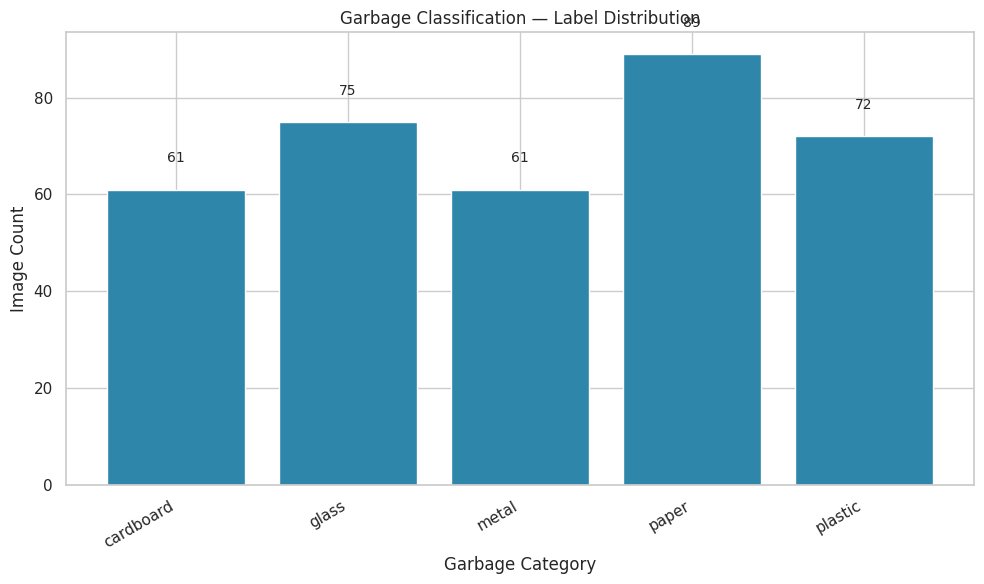

{0: 61, 1: 75, 2: 61, 3: 89, 4: 72}

[DONE] Cell executed successfully.


In [37]:
# Category Distribution in Validation Dataset
val_labeled_garbage: ClassLabel = [
        {"image_path" : each_path, "categ_int" : each_ctg}
        for each_path, each_ctg in zip(val_paths, val_ctg)
    ]

viz_label_distribution(
    labeled_garbages = val_labeled_garbage,
    int_to_name = int_to_name,
)


[RUN] # Category Distribution in Test Dataset


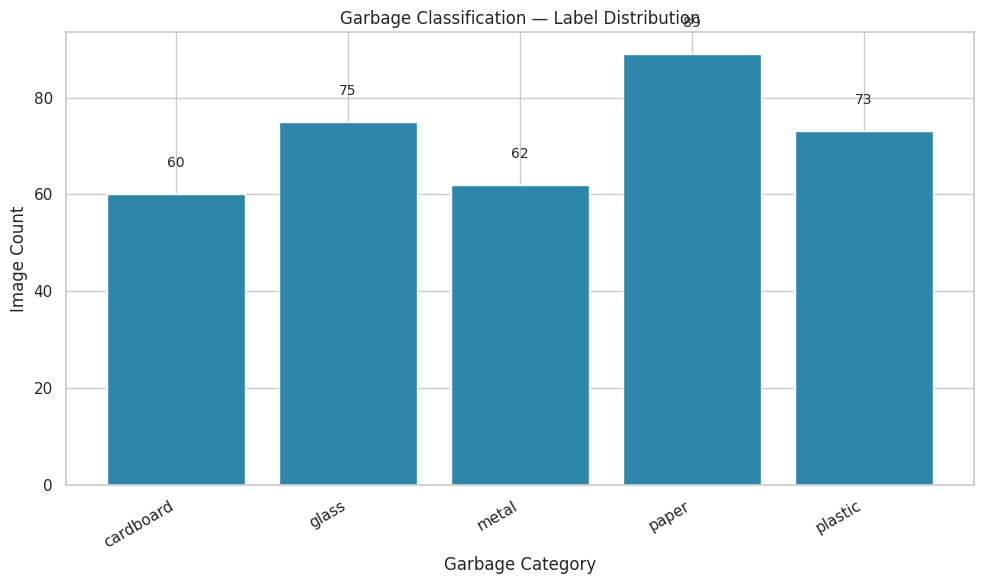

{0: 60, 1: 75, 2: 62, 3: 89, 4: 73}

[DONE] Cell executed successfully.


In [38]:
# Category Distribution in Test Dataset
test_labeled_garbage: ClassLabel = [
        {"image_path" : each_path, "categ_int" : each_ctg}
        for each_path, each_ctg in zip(test_paths, test_ctg)
    ]

viz_label_distribution(
    labeled_garbages = test_labeled_garbage,
    int_to_name = int_to_name,
)


## Data Pipeline — TensorFlow Dataset Construction

With the resize utility defined and the dataset partitioned into train / validation / test splits, the following utility functions construct the TensorFlow `tf.data.Dataset` pipeline.

The pipeline performs four operations per sample:
1. **I/O — image loading from disk** via `tf.py_function`, which provides an escape hatch to arbitrary Python code (PIL, NumPy) within the TF computational graph,
2. **Spatial transform** — resize + centre crop using the utility functions defined above,
3. **Normalisation** — scale pixel values from `[0, 255]` to `[0.0, 1.0]` by dividing by 255,
4. **Batching and prefetching** — group samples into fixed-size batches and overlap I/O with GPU computation using `tf.data.AUTOTUNE`.

**Trade-off note:** using `tf.py_function` prevents full graph-mode parallelisation within the map step. This is an acceptable trade-off here given the dataset size (~2,400 images), where disk I/O — rather than CPU preprocessing — is typically the bottleneck.


In [39]:
def load_and_preprocess_image_py(
        image_path_tensor: tf.Tensor
) -> tf.Tensor:

    image_path: str = image_path_tensor.numpy().decode("utf-8")

    with Image.open(image_path) as img:
        rc_image_np: np.ndarray = resize_and_crop_image(img = img)

    rc_image_np = rc_image_np.astype(np.float32) / 255.0

    rc_image_tf: tf.Tensor = tf.convert_to_tensor(rc_image_np)

    return rc_image_tf


def tf_preprocess_wrapper(
        image_path: tf.Tensor
        , label: tf.Tensor
) -> Tuple[tf.Tensor, tf.Tensor]:

    image: tf.Tensor = tf.py_function(
        func = load_and_preprocess_image_py
        , inp = [image_path]
        , Tout = tf.float32
    )

    image.set_shape((224, 224, 3))

    return image, label

print("Image preprocessing functions are ready: load_and_preprocess_image_py + tf_preprocess_wrapper")

[RUN] def load_and_preprocess_image_py(
Image preprocessing functions are ready: load_and_preprocess_image_py + tf_preprocess_wrapper
[DONE] Cell executed successfully.


In [40]:
## Hugging Face Authentication
## Token resolution priority: env HF_TOKEN → Colab Secret HF_TOKEN → cred/hf_token.json → interactive prompt

import json
import huggingface_hub as hf

hf_token_value: str = read_token_with_fallback(
    secret_name="HF_TOKEN",
    env_name="HF_TOKEN",
    prompt_label="Hugging Face token",
    prompt_if_missing=False,
)

if not hf_token_value:
    hf_token_path: Path = project_root / "cred" / "hf_token.json"
    if hf_token_path.exists():
        with open(hf_token_path, mode="r", encoding="utf-8") as tkp:
            hf_token: Dict = json.load(tkp)
        hf_token_value = str(hf_token.get("value", "")).strip()
        if hf_token_value:
            os.environ["HF_TOKEN"] = hf_token_value
            print("[TOKEN] HF_TOKEN loaded from cred/hf_token.json.")

if not hf_token_value:
    hf_token_value = read_token_with_fallback(
        secret_name="HF_TOKEN",
        env_name="HF_TOKEN",
        prompt_label="Hugging Face token",
        prompt_if_missing=True,
    )

if not hf_token_value:
    raise ValueError(
        "Hugging Face token not found. "
        "Set the HF_TOKEN environment variable, populate cred/hf_token.json, or enter the token at the prompt."
    )

hf.login(token=hf_token_value)
print("[HF] Hugging Face login successful.")


[RUN] ## Hugging Face Authentication
[INFO] Colab Secret 'HF_TOKEN' is skipped because ENABLE_COLAB_SECRETS=False. The notebook will use an environment variable or an interactive prompt instead.
[INFO] Colab Secret 'HF_TOKEN' is skipped because ENABLE_COLAB_SECRETS=False. The notebook will use an environment variable or an interactive prompt instead.
[TOKEN] HF_TOKEN loaded from interactive prompt.


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


[HF] Hugging Face login successful.
[DONE] Cell executed successfully.


In [41]:
def build_dataset_from_labeled_images(
        labeled_images: ClassLabel
        , batch_size: int = 32
        , is_training: bool = False
) -> tf.data.Dataset:

    image_paths, labels = prepare_records(labeled_images = labeled_images)

    dst: tf.data.Dataset = tf.data.Dataset.from_tensor_slices(
        tensors = (image_paths, labels)
    )

    if is_training:
        dst = dst.shuffle(buffer_size = len(image_paths))

    dst = dst.map(tf_preprocess_wrapper, num_parallel_calls = tf.data.AUTOTUNE)
    dst = dst.batch(batch_size = batch_size)
    dst = dst.prefetch(buffer_size = tf.data.AUTOTUNE)

    return dst

[RUN] def build_dataset_from_labeled_images(
[DONE] Cell executed successfully.


In [42]:
import tensorflow as tf

# ViT-Large requires substantially more VRAM than ViT-Base (~307M vs ~86M parameters).
# Keep a conservative fallback batch size for T4 GPUs.
PREFERRED_BATCH_SIZE: int = 16
FALLBACK_BATCH_SIZE: int = 8
BATCH_SIZE: int = PREFERRED_BATCH_SIZE
EPOCHS: int = 30


def rebuild_training_datasets(batch_size: int) -> None:
    """Rebuild train/val/test datasets with a new batch size."""
    global BATCH_SIZE, train_ds, val_ds, test_ds
    BATCH_SIZE = batch_size

    train_ds = build_dataset_from_labeled_images(
        labeled_images=train_labeled_garbage,
        batch_size=BATCH_SIZE,
        is_training=True,
    )

    val_ds = build_dataset_from_labeled_images(
        labeled_images=val_labeled_garbage,
        batch_size=BATCH_SIZE,
        is_training=False,
    )

    test_ds = build_dataset_from_labeled_images(
        labeled_images=test_labeled_garbage,
        batch_size=BATCH_SIZE,
        is_training=False,
    )


rebuild_training_datasets(batch_size=BATCH_SIZE)

# Audit-friendly pipeline summary
train_cardinality = tf.data.experimental.cardinality(train_ds).numpy()
val_cardinality = tf.data.experimental.cardinality(val_ds).numpy()
test_cardinality = tf.data.experimental.cardinality(test_ds).numpy()

sample_images, sample_labels = next(iter(train_ds.take(1)))

print("[DATASET PIPELINE SUMMARY]")
print(f"Batch size               : {BATCH_SIZE} (preferred={PREFERRED_BATCH_SIZE}, fallback={FALLBACK_BATCH_SIZE})")
print(f"Train steps/epoch        : {train_cardinality}")
print(f"Validation steps/epoch   : {val_cardinality}")
print(f"Test steps               : {test_cardinality}")
print(f"Sample train batch shape : {sample_images.shape}")
print(f"Sample label shape       : {sample_labels.shape}")


[RUN] import tensorflow as tf
[DATASET PIPELINE SUMMARY]
Batch size               : 16 (preferred=16, fallback=8)
Train steps/epoch        : 105
Validation steps/epoch   : 23
Test steps               : 23
Sample train batch shape : (16, 224, 224, 3)
Sample label shape       : (16,)
[DONE] Cell executed successfully.


In [43]:
from transformers import ViTImageProcessor
import tensorflow as tf
import os

# Select the ViT variant: "base" (86M params) or "large" (307M params).
# This notebook uses "large" for improved texture discrimination capacity.
VIT_VARIANT: str = "large"

VIT_MODEL_MAP: Dict[str, str] = {
    "base": "google/vit-base-patch16-224",
    "large": "google/vit-large-patch16-224",
}

if VIT_VARIANT not in VIT_MODEL_MAP:
    raise ValueError(f"VIT_VARIANT must be one of {list(VIT_MODEL_MAP.keys())}.")

PRETRAINED_MODEL: str = VIT_MODEL_MAP[VIT_VARIANT]
print(f"[MODEL] Selected pre-trained model: {PRETRAINED_MODEL}")

hf_download_token: str = os.getenv("HF_TOKEN", "").strip()
hf_token_arg = hf_download_token if hf_download_token else False
if hf_download_token:
    print("[HF] HF_TOKEN found in environment — authenticated model download.")
else:
    print("[HF] HF_TOKEN not found — attempting anonymous model download.")

vit_hf_processor: ViTImageProcessor = ViTImageProcessor.from_pretrained(
    PRETRAINED_MODEL,
    token=hf_token_arg,
)
print(f"[MODEL] ViTImageProcessor loaded. Image mean: {vit_hf_processor.image_mean}")


[RUN] from transformers import ViTImageProcessor
[MODEL] Selected pre-trained model: google/vit-large-patch16-224
[HF] HF_TOKEN found in environment — authenticated model download.
[MODEL] ViTImageProcessor loaded. Image mean: [0.5, 0.5, 0.5]
[DONE] Cell executed successfully.


In [44]:
from typing import Tuple, Dict

IMAGE_MEAN: tf.Tensor = tf.constant(
    vit_hf_processor.image_mean
    , dtype = tf.float32
)

IMAGE_STD: tf.Tensor = tf.constant(
    vit_hf_processor.image_std
    , dtype = tf.float32
)

def to_vit_inputs(
        images: tf.Tensor
        , labels: tf.Tensor
) -> Tuple[Dict[str, tf.Tensor], tf.Tensor]:
    """
    Convert standard image batch into HuggingFace ViT input format.

    Args:
        images: Tensor of shape (B, H, W, C), dtype=tf.float32, range [0, 1]
        labels: Tensor of shape (B,), dtype=tf.int32 or tf.int64

    Returns:
        inputs: Dict with key "pixel_values" → (B, C, H, W)
        labels: unchanged
    """

    # ------------------------------------------------------------------
    # Type enforcement
    # ------------------------------------------------------------------
    images = tf.cast(images, dtype=tf.float32)

    # ------------------------------------------------------------------
    # Shape validation (useful for debugging)
    # ------------------------------------------------------------------
    tf.debugging.assert_rank(images, 4, message="Images must be rank-4 tensor")
    tf.debugging.assert_equal(
        tf.shape(images)[-1],
        3,
        message="Images must have 3 channels (RGB)"
    )

    # ------------------------------------------------------------------
    # Normalization (match ViT pretraining)
    # ------------------------------------------------------------------
    normalized_images: tf.Tensor = (images - IMAGE_MEAN) / IMAGE_STD

    # ------------------------------------------------------------------
    # Convert NHWC → NCHW (required by HuggingFace ViT)
    # ------------------------------------------------------------------
    pixel_values: tf.Tensor = tf.transpose(
        normalized_images,
        perm=[0, 3, 1, 2]
    )

    # ------------------------------------------------------------------
    # Return in HuggingFace expected format
    # ------------------------------------------------------------------
    inputs: Dict[str, tf.Tensor] = {
        "pixel_values": pixel_values
    }

    return inputs, labels

[RUN] from typing import Tuple, Dict
[DONE] Cell executed successfully.


In [45]:
# ------------------------------------------------------------------
# Apply to Dataset Pipelines
# ------------------------------------------------------------------

train_vit_ds: tf.data.Dataset = train_ds.map(
    to_vit_inputs,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_vit_ds: tf.data.Dataset = val_ds.map(
    to_vit_inputs,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_vit_ds: tf.data.Dataset = test_ds.map(
    to_vit_inputs,
    num_parallel_calls=tf.data.AUTOTUNE
)

[RUN] # ------------------------------------------------------------------
[DONE] Cell executed successfully.


In [46]:
import tensorflow as tf

try:
    from transformers import TFViTModel
    TFViTModelClass = TFViTModel
    print("[IMPORT] TFViTModel imported successfully.")
except Exception as err:
    raise RuntimeError(
        "TFViTModel is unavailable in the current environment. "
        "Re-run the dependency installation cell, restart the kernel, "
        "and then re-execute from this import cell."
    ) from err


[RUN] import tensorflow as tf
[IMPORT] TFViTModel imported successfully.
[DONE] Cell executed successfully.


## Model Architecture — Vision Transformer Large (ViT-L/16)

Rather than training a ViT from scratch, this notebook employs transfer learning from **`google/vit-large-patch16-224`** — a large-scale pre-trained model available on Hugging Face. The backbone was first pre-trained on **ImageNet-21k** (14 million images, 21,841 classes) and subsequently fine-tuned on **ImageNet-1k** (1.28 million images, 1,000 classes).

### Architecture Specifications (ViT-Large)

| Parameter | Value |
|---|---|
| Input resolution | 224 × 224 × 3 (RGB) |
| Patch size | 16 × 16 px |
| Number of patches | 14 × 14 = **196 tokens** |
| Hidden dimension (D) | **1,024** |
| Transformer encoder layers | **24** |
| Self-attention heads | **16** |
| MLP expansion ratio | 4× hidden dim = 4,096 |
| Total parameters | **~307 million** |
| CLS token | Prepended to patch sequence; its final hidden state is used for classification |

> **ViT-Large vs. ViT-Base**: ViT-Large provides approximately 3.6× more parameters (307M vs. 86M) and deeper contextual representations (24 vs. 12 layers, hidden dim 1,024 vs. 768). This capacity increase is expected to improve discrimination between visually similar classes such as cardboard and paper, at the cost of higher GPU memory consumption and longer training time.

### Fine-Tuning Strategy

A **two-stage** approach is adopted to mitigate catastrophic forgetting on this small dataset (~2,400 images):

1. **Stage 1 — Head-only training**: the pre-trained backbone is frozen; only the new classification `Dense` layer is trained. This warms up the classification head before backbone weights are disturbed.
2. **Stage 2 — Full fine-tuning**: the backbone is unfrozen; the entire model is trained jointly at a significantly reduced learning rate (`1e-5`) to preserve the embedded knowledge from pre-training.

> **Implementation note:** `ViTClassifier` is a subclassed `tf.keras.Model`. The standard `.keras` serialisation format does not support full subclassed model saving. Weights are therefore persisted via `ModelCheckpoint(save_weights_only=True)` to `.weights.h5` files.


### Discussion - Class Weighting vs. Alternative Imbalance Mitigation Strategies

#### Mechanism of Class Weighting
`sklearn.utils.class_weight.compute_class_weight("balanced", ...)` assigns each class a weight inversely proportional to its frequency in the training set. The effective loss for each sample is then scaled by its class weight:

$$w_c = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_{\text{samples},\, c}}$$

In this dataset (after excluding `trash`), the class distribution is moderately imbalanced (403 to 594 samples, ratio approximately 1.47:1). Therefore, weighting is expected to provide a mild correction without strongly destabilizing optimization.

#### Comparison with Alternative Strategies

| Strategy | Mechanism | Advantages | Limitations |
|---|---|---|---|
| **Class weighting** *(selected)* | Scale loss per sample by inverse class frequency | No data duplication overhead; simple to implement; preserves original dataset composition | Does not add new visual diversity to minority classes |
| **Random oversampling** | Duplicate minority samples | Balances mini-batch class counts | Higher overfitting risk on repeated minority examples |
| **SMOTE / synthetic sampling** | Generate minority samples by interpolation in feature space | Adds synthetic diversity | Less direct for raw images; usually requires feature-space pipeline |
| **Undersampling** | Reduce majority samples | Faster training | Discards potentially informative data |
| **Targeted augmentation** | Stronger augmentation on minority classes | Adds task-relevant visual variation | Requires careful augmentation design and validation |

#### Justification for This Dataset
Given the **moderate** imbalance in the five-class modelling subset (maximum ratio approximately 1.47:1), class weighting is a pragmatic baseline because:
- It preserves training efficiency,
- It avoids distribution distortion from duplicated samples,
- It is generally suitable for mild-to-moderate imbalance.

If `trash` were retained (imbalance ratio approximately 4.3:1), class weighting alone would likely be insufficient; targeted augmentation and/or controlled oversampling would become more appropriate.


In [47]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

active_label_ids = sorted(set(train_ctg))

# Assert (check) if the Label Integer (idx) is continuous
# If the idx is not continuous, then `assert` will throw `AssertionError`
assert active_label_ids == list(range(len(active_label_ids))), (
    "Labels must be contiguous integers starting from 0 before fine-tuning ViT."
)

active_label_names = [
    each_name
    for each_name, each_idx in sorted(categ_dict.items(), key=lambda item: item[1])
    if each_idx in active_label_ids
]

NUM_LABELS: int = len(active_label_ids)

id2label = {idx: name for idx, name in enumerate(active_label_names)}
label2id = {name: idx for idx, name in id2label.items()}

# Tell scikitlearn to assign more weight to smaller class
# Without `compute_class_weight`, the model would tends to be dominated
# by the predominant class.
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(active_label_ids),
    y=np.array(train_ctg),
)
class_weight_dict = {idx: float(weight) for idx, weight in zip(active_label_ids, class_weights)}

print("[TRAINING SETUP SUMMARY]")
print(f"Num classes      : {NUM_LABELS}")
print(f"Label IDs active : {active_label_ids}")
print("id2label:")
print(id2label)

print("class_weight_dict:")
print(class_weight_dict)


[RUN] from sklearn.utils.class_weight import compute_class_weight
[TRAINING SETUP SUMMARY]
Num classes      : 5
Label IDs active : [0, 1, 2, 3, 4]
id2label:
{0: 'cardboard', 1: 'glass', 2: 'metal', 3: 'paper', 4: 'plastic'}
class_weight_dict:
{0: 1.1865248226950356, 1: 0.9532763532763533, 2: 1.1658536585365853, 3: 0.8043269230769231, 4: 0.9928783382789318}
[DONE] Cell executed successfully.


## 🧠 Food For Thoughts

The notebook uses class weighting to handle class imbalance during training. How class weighting affects model training compared to other alternatives such as oversampling, undersampling, or targeted augmentation? Further, what are the tradeoffs of that choice for this dataset?

### Discussion — Class Weighting vs. Alternative Imbalance Mitigation Strategies

#### Mechanism of Class Weighting

`sklearn.utils.class_weight.compute_class_weight("balanced", ...)` assigns each class a weight that is inversely proportional to its frequency in the training set. The effective loss for each sample is then scaled by its class weight, causing the model to penalise errors on minority classes more heavily:

$$w_c = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_{\text{samples},\, c}}$$

In the present dataset (after excluding the `trash` class), the class distribution is moderately imbalanced — the range spans from 403 (cardboard) to 594 (paper), a ratio of approximately 1.47:1. Consequently, the resulting weights are modest and do not introduce instability into the optimisation.

#### Comparison with Alternative Strategies

| Strategy | Mechanism | Advantages | Limitations |
|---|---|---|---|
| **Class weighting** *(selected)* | Scale loss per sample by inverse class frequency | Zero data overhead; easy to implement; does not alter dataset distribution | Does not increase feature diversity for minority classes |
| **Random oversampling** | Duplicate minority-class samples | Equalises mini-batch class counts | High risk of overfitting on duplicated minority samples |
| **SMOTE** | Synthesise new minority samples via interpolation in feature space | Introduces genuine diversity | Computationally expensive; not straightforward for raw image data |
| **Undersampling** | Discard majority-class samples | Reduces training time | Discards potentially informative majority samples |
| **Targeted augmentation** | Apply stronger augmentation exclusively to minority classes | Adds authentic visual variation | Requires domain-specific knowledge to design effective transforms |

#### Justification for This Dataset

Given that the class imbalance in the five-class modelling dataset is **moderate** (maximum ratio ≈ 1.47:1), class weighting is the most pragmatic choice because:
- It introduces no additional data volume, preserving training efficiency,
- It maintains the representational fidelity of the original distribution,
- It is well-suited to mild-to-moderate imbalance regimes.

If the `trash` class were retained (imbalance ratio ≈ 4.3:1), targeted augmentation or stratified oversampling would be more appropriate, as class weighting alone would not suffice to bridge such a large distributional gap.


In [48]:
data_augmentation = tf.keras.Sequential(
    layers=[
        tf.keras.layers.RandomFlip(mode="horizontal"),
        tf.keras.layers.RandomRotation(factor=0.05),
        tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    ],
    name="train_augmentation",
)

def augment_batch(
        images: tf.Tensor,
        labels: tf.Tensor,
) -> Tuple[tf.Tensor, tf.Tensor]:
    # Augmentation is applied on-the-fly (stochastic per epoch iteration).
    # No fixed augmented copies are pre-generated or stored to disk.
    augmented_images: tf.Tensor = data_augmentation(images, training=True)
    augmented_images = tf.clip_by_value(augmented_images, 0.0, 1.0)
    return augmented_images, labels

train_aug_ds: tf.data.Dataset = train_ds.map(
    augment_batch,
    num_parallel_calls=tf.data.AUTOTUNE,
)

train_vit_ds_aug: tf.data.Dataset = train_aug_ds.map(
    to_vit_inputs,
    num_parallel_calls=tf.data.AUTOTUNE,
).prefetch(tf.data.AUTOTUNE)

print("[AUGMENTATION] Online augmentation pipeline built: RandomFlip + RandomRotation + RandomZoom.")


[RUN] data_augmentation = tf.keras.Sequential(
[AUGMENTATION] Online augmentation pipeline built: RandomFlip + RandomRotation + RandomZoom.
[DONE] Cell executed successfully.


In [49]:
import os

hf_download_token: str = os.getenv("HF_TOKEN", "").strip()
hf_token_arg = hf_download_token if hf_download_token else False

# Load pre-trained ViT-Large backbone from Hugging Face.
# from_pt=True tells the TF backend to convert PyTorch weights;
# use_safetensors=False falls back to the .bin checkpoint for compatibility.
vit_backbone = TFViTModelClass.from_pretrained(
    PRETRAINED_MODEL,
    from_pt=True,
    use_safetensors=False,
    token=hf_token_arg,
)


class ViTClassifier(tf.keras.Model):
    """Garbage classification head on top of a pre-trained ViT backbone.

    The CLS token representation (index 0 of last_hidden_state) is passed
    through a single Dense softmax layer to produce class probabilities.
    """

    def __init__(self, backbone: TFViTModelClass, num_labels: int):
        super().__init__(name="garbage_vit_classifier")
        self.backbone = backbone
        self.classifier = tf.keras.layers.Dense(
            num_labels,
            activation="softmax",
            name="classifier",
        )

    def call(self, inputs, training=False):
        pixel_values = inputs["pixel_values"] if isinstance(inputs, dict) else inputs
        vit_outputs = self.backbone(pixel_values=pixel_values, training=training)
        cls_token = vit_outputs.last_hidden_state[:, 0, :]  # CLS token
        return self.classifier(cls_token)


# Stage 1: freeze backbone — train classification head only
vit_backbone.trainable = False
vit_model = ViTClassifier(backbone=vit_backbone, num_labels=NUM_LABELS)

# Build model with a concrete dummy tensor to avoid KerasTensor incompatibilities
_ = vit_model({"pixel_values": tf.zeros((1, 3, 224, 224), dtype=tf.float32)}, training=False)

vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

vit_model.summary()


[RUN] import os


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFViTModel: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFViTModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFViTModel were not initialized from the PyTorch model and are newly initialized: ['vit.pooler.dense.weight', 'vit.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "garbage_vit_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ classifier (Dense)              │ (1, 5)                 │         5,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,125 (20.02 KB)

 Trainable params: 5,125 (20.02 KB)

 Non-trainable params: 0 (0.00 B)

[DONE] Cell executed successfully.


In [50]:
## Pre-run safety check for ViT-Large

# 1) Ensure critical objects exist
required_vars = [
    "train_vit_ds_aug",
    "val_vit_ds",
    "test_vit_ds",
    "vit_model",
    "class_weight_dict",
]

missing_vars = [var_name for var_name in required_vars if var_name not in globals()]
if missing_vars:
    raise RuntimeError(f"Missing required variables before training: {missing_vars}. Run previous cells first.")

# 2) One-batch forward pass sanity check
sample_inputs, sample_labels = next(iter(train_vit_ds_aug.take(1)))
sample_probs = vit_model(sample_inputs, training=False)

print("[SAFETY CHECK]")
print(f"Pixel values shape  : {sample_inputs['pixel_values'].shape}")
print(f"Label batch shape   : {sample_labels.shape}")
print(f"Model output shape  : {sample_probs.shape}")
print(f"Current batch size  : {BATCH_SIZE}")
print("Sanity check passed. Training is ready to start.")


[RUN] ## Pre-run safety check for ViT-Large
[SAFETY CHECK]
Pixel values shape  : (16, 3, 224, 224)
Label batch shape   : (16,)
Model output shape  : (16, 5)
Current batch size  : 16
Sanity check passed. Training is ready to start.
[DONE] Cell executed successfully.


## 🧠 Food for Thought

The model is initialised from `google/vit-large-patch16-224`, with the ViT backbone frozen during Stage 1 before being released for full fine-tuning in Stage 2. What are the theoretical benefits of this two-stage strategy on a relatively small dataset (~2,400 images), and what diagnostic signals would indicate that full fine-tuning is genuinely improving generalisation rather than causing overfitting?


### Discussion — Two-Stage Fine-Tuning: Theoretical Benefits and Overfitting Diagnostics

#### Why Freeze the Backbone First?

`google/vit-large-patch16-224` encodes 307 million parameters learned from 14 million diverse ImageNet images. These parameters represent a rich hierarchy of visual features — low-level edge detectors through mid-level texture representations up to high-level semantic patterns — that are directly transferable to garbage classification.

**Stage 1 — frozen backbone:**
- The randomly initialised classification head initially generates high-magnitude, noisy gradients. If backpropagated through the entire 307M-parameter backbone, these gradients would irreversibly corrupt the embedded representations — a phenomenon known as **catastrophic forgetting**.
- Freezing the backbone confines gradient flow to the head, allowing the classification weights to stabilise against the fixed feature representations before any fine-grained backbone adaptation begins.

**Stage 2 — full fine-tuning at reduced learning rate:**
- Once the head has converged to a sensible initialisation, the backbone is released. The reduced learning rate (`1e-5` vs. `1e-4` in Stage 1) ensures that updates to the pre-trained backbone are small and incremental — refining the feature representations for the garbage domain without erasing the general-purpose knowledge acquired during pre-training.
- This approach is particularly important for ViT-Large (24 layers), where deeper, more abstract representations accumulated over 24 stacked transformer blocks are both more powerful and more sensitive to large gradient updates.

#### Diagnostic Signals for Generalisation vs. Overfitting

| Observation | Interpretation |
|---|---|
| Validation loss decreases in Stage 2 | Full fine-tuning is beneficial; backbone is successfully adapting to the garbage domain |
| Validation loss plateaus or increases in Stage 2 | Overfitting onset — the model is memorising training data; `EarlyStopping` should intervene |
| `train_loss` ≪ `val_loss` (widening gap) | Generalisation degradation; reduce LR or apply stronger regularisation |
| `EarlyStopping` fires at low epoch count | Strong signal that full fine-tuning has reached its useful maximum for this dataset |
| Stage 2 accuracy gain < 1–2% over Stage 1 | Marginal benefit; consider whether the computational cost justifies the fine-tuning |

In the stored run for this notebook, Stage 2 improved the validation trajectory beyond the best Stage 1 checkpoint: **val_accuracy** rose from **0.8380** to **0.8827**, while **val_loss** decreased from **0.4325** to **0.3610**. This indicates that unfreezing the backbone provided a real generalisation gain rather than merely memorising the training set.

The remaining train-vs-validation gap is still modest enough to be acceptable for this dataset size. Near the end of training, training accuracy is in the mid-to-high 0.86 range while validation accuracy remains around **0.88**, so the final run does not show a severe overfitting divergence.

#### Dataset Scale Considerations

With ~2,400 training images distributed across 5 classes (~480 images/class), this dataset is **small by ViT standards** — ViT-Large was designed for datasets orders of magnitude larger. The two-stage strategy is particularly well-suited here because:
- Sufficient pre-trained features exist (ImageNet textures closely parallel garbage material appearance),
- Full training from scratch would be severely data-limited and prone to overfitting,
- The frozen-then-unfreeze protocol maximally leverages the pre-trained representations while still allowing task-specific adaptation.

In [51]:
HEAD_EPOCHS: int = 5
FINE_TUNE_EPOCHS: int = 10

# Mount Google Drive for checkpoint persistence when running on Colab.
# Falls back to a local project directory in non-Colab environments.
try:
    import google.colab  # type: ignore
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    checkpoint_dir: Path = Path("/content/drive/MyDrive/forum06_checkpoints/vit_large")
except ImportError:
    checkpoint_dir = project_root / "checkpoints" / "vit_large"

checkpoint_dir.mkdir(parents=True, exist_ok=True)
print(f"[CHECKPOINT] Checkpoint directory: {checkpoint_dir.resolve()}")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
    # Persist best model weights (minimum validation loss)
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_dir / "best_vit_model.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    # Per-epoch recovery checkpoints
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_dir / "vit_epoch_{epoch:02d}.weights.h5"),
        save_best_only=False,
        save_weights_only=True,
        save_freq="epoch",
    ),
    # Sub-epoch recovery for Colab session interruptions
    tf.keras.callbacks.BackupAndRestore(
        backup_dir=str(checkpoint_dir / "backup"),
    ),
    # Training history for post-hoc analysis
    tf.keras.callbacks.CSVLogger(
        filename=str(checkpoint_dir / "training_log.csv"),
        append=True,
    ),
]

print("[STAGE 1] Head-only training — backbone frozen.")
try:
    history_head = vit_model.fit(
        train_vit_ds_aug,
        validation_data=val_vit_ds,
        epochs=HEAD_EPOCHS,
        callbacks=callbacks,
        class_weight=class_weight_dict,
    )
except tf.errors.ResourceExhaustedError:
    print("[OOM] ResourceExhaustedError detected in Stage 1. Rebuilding datasets with fallback batch size...")
    rebuild_training_datasets(batch_size=FALLBACK_BATCH_SIZE)

    # Rebuild ViT-formatted and augmented pipelines with the new batch size
    train_vit_ds = train_ds.map(to_vit_inputs, num_parallel_calls=tf.data.AUTOTUNE)
    val_vit_ds = val_ds.map(to_vit_inputs, num_parallel_calls=tf.data.AUTOTUNE)
    test_vit_ds = test_ds.map(to_vit_inputs, num_parallel_calls=tf.data.AUTOTUNE)

    train_aug_ds = train_ds.map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE)
    train_vit_ds_aug = train_aug_ds.map(
        to_vit_inputs,
        num_parallel_calls=tf.data.AUTOTUNE,
    ).prefetch(tf.data.AUTOTUNE)

    print(f"[OOM] Retry Stage 1 with fallback batch size: {BATCH_SIZE}")
    history_head = vit_model.fit(
        train_vit_ds_aug,
        validation_data=val_vit_ds,
        epochs=HEAD_EPOCHS,
        callbacks=callbacks,
        class_weight=class_weight_dict,
    )


[RUN] HEAD_EPOCHS: int = 5
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[CHECKPOINT] Checkpoint directory: /content/drive/MyDrive/forum06_checkpoints/vit_large
[STAGE 1] Head-only training — backbone frozen.
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5449 - loss: 1.1905
Epoch 2: val_loss improved from None to 0.79399, saving model to /content/drive/MyDrive/forum06_checkpoints/vit_large/best_vit_model.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/forum06_checkpoints/vit_large/best_vit_model.weights.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.6079 - loss: 1.0513 - val_accuracy: 0.6983 - val_loss: 0.7940 - learning_rate: 1.0000e-04
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7263 - loss: 0.7881
Epoch 3: val_loss improved from 0.79399 to 0.60693, saving model to /content/drive/MyDrive/forum06_checkpoints/vit_large/best_vit_model.

In [52]:
vit_backbone.trainable = True

vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4,
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

print("[STAGE 2] Full fine-tuning — backbone unfrozen.")
try:
    history_finetune = vit_model.fit(
        train_vit_ds_aug,
        validation_data=val_vit_ds,
        initial_epoch=HEAD_EPOCHS,
        epochs=HEAD_EPOCHS + FINE_TUNE_EPOCHS,
        callbacks=callbacks,
        class_weight=class_weight_dict,
    )
except tf.errors.ResourceExhaustedError:
    print("[OOM] ResourceExhaustedError detected in Stage 2. Rebuilding datasets with fallback batch size...")
    rebuild_training_datasets(batch_size=FALLBACK_BATCH_SIZE)

    train_vit_ds = train_ds.map(to_vit_inputs, num_parallel_calls=tf.data.AUTOTUNE)
    val_vit_ds = val_ds.map(to_vit_inputs, num_parallel_calls=tf.data.AUTOTUNE)
    test_vit_ds = test_ds.map(to_vit_inputs, num_parallel_calls=tf.data.AUTOTUNE)

    train_aug_ds = train_ds.map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE)
    train_vit_ds_aug = train_aug_ds.map(
        to_vit_inputs,
        num_parallel_calls=tf.data.AUTOTUNE,
    ).prefetch(tf.data.AUTOTUNE)

    print(f"[OOM] Retry Stage 2 with fallback batch size: {BATCH_SIZE}")
    history_finetune = vit_model.fit(
        train_vit_ds_aug,
        validation_data=val_vit_ds,
        initial_epoch=HEAD_EPOCHS,
        epochs=HEAD_EPOCHS + FINE_TUNE_EPOCHS,
        callbacks=callbacks,
        class_weight=class_weight_dict,
    )


[RUN] vit_backbone.trainable = True
[STAGE 2] Full fine-tuning — backbone unfrozen.
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8573 - loss: 0.4557
Epoch 2: val_loss improved from 0.43253 to 0.42571, saving model to /content/drive/MyDrive/forum06_checkpoints/vit_large/best_vit_model.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/forum06_checkpoints/vit_large/best_vit_model.weights.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8518 - loss: 0.4599 - val_accuracy: 0.8436 - val_loss: 0.4257 - learning_rate: 1.0000e-05
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8578 - loss: 0.4731
Epoch 3: val_loss improved from 0.42571 to 0.41983, saving model to /content/drive/MyDrive/forum06_checkpoints/vit_large/best_vit_model.weights.h5

Epoch 3: finished saving model to /content/drive/MyDrive/forum06_checkpoints/vit_large/best_vit_model.weights.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8613 - loss: 0.4547 - 

In [53]:
test_metrics = vit_model.evaluate(test_vit_ds, return_dict=True)

print("[TEST EVALUATION SUMMARY]")
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

test_metrics


[RUN] test_metrics = vit_model.evaluate(test_vit_ds, return_dict=True)
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 881ms/step - accuracy: 0.8635 - loss: 0.4224
[TEST EVALUATION SUMMARY]
accuracy: 0.8635
loss: 0.4224


{'accuracy': 0.8635097742080688, 'loss': 0.42235222458839417}

[DONE] Cell executed successfully.


[RUN] from matplotlib import pyplot as plt


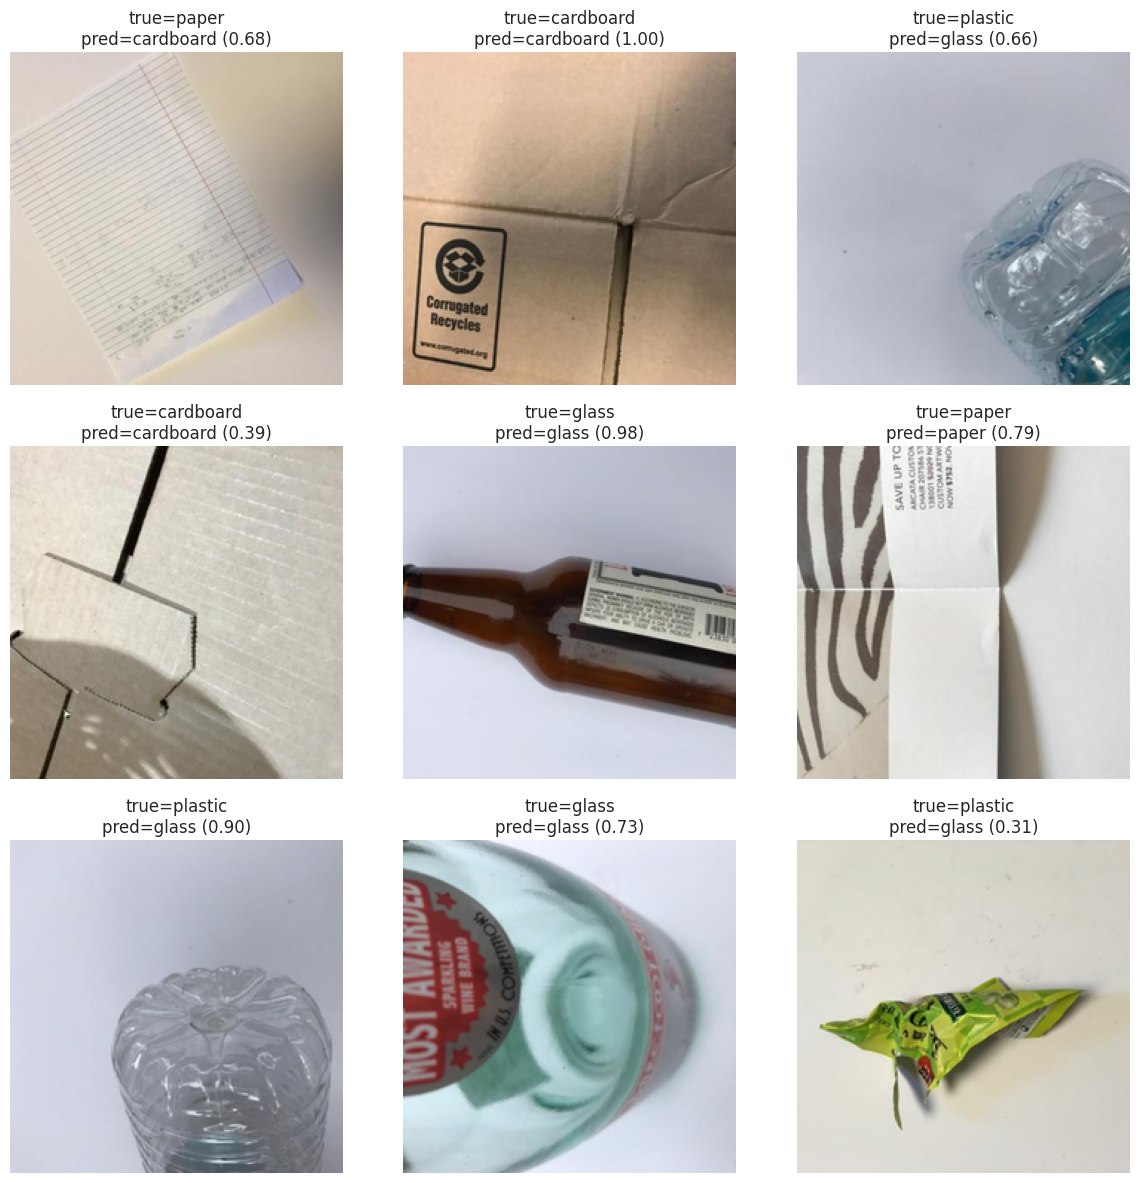

[DONE] Cell executed successfully.


In [54]:
from matplotlib import pyplot as plt

def show_vit_predictions(
        dataset: tf.data.Dataset
        , model: tf.keras.Model
        , id2label: Dict[int, str]
        , max_images: int = 9
) -> None:

    batch_inputs, batch_labels = next(iter(dataset.take(1)))

    probs = model(batch_inputs, training=False)
    pred_ids = tf.argmax(probs, axis=-1)

    images = tf.transpose(batch_inputs["pixel_values"], perm=[0, 2, 3, 1])
    images = (images * IMAGE_STD) + IMAGE_MEAN
    images = tf.clip_by_value(images, 0.0, 1.0)

    total_images = min(max_images, images.shape[0])
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    for idx in range(total_images):
        axes[idx].imshow(images[idx].numpy())
        true_label = id2label[int(batch_labels[idx].numpy())]
        pred_label = id2label[int(pred_ids[idx].numpy())]
        pred_prob = float(probs[idx, pred_ids[idx]].numpy())
        axes[idx].set_title(
            f"true={true_label}\npred={pred_label} ({pred_prob:.2f})"
        )
        axes[idx].axis("off")

    for idx in range(total_images, len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

show_vit_predictions(
    dataset=test_vit_ds,
    model=vit_model,
    id2label=id2label,
)


---

## Challenges Encountered

The following technical and methodological challenges arose during the development of this notebook:

### 1. Compute Resource Constraints
`google/vit-large-patch16-224` contains approximately **307 million parameters** - roughly 3.6x more than the base variant. Training on a local CPU is impractical; even on a Colab T4 GPU (16 GB VRAM), ViT-Large requires careful batch-size control to avoid out-of-memory (OOM) errors.

### 2. Dual Token Authentication
The pipeline requires two independent API tokens: a **Kaggle API Token** (dataset download) and a **Hugging Face Token** (model download). Managing both tokens securely across different environments (VS Code, Colab UI, CI/CD) required a multi-tier fallback strategy.

### 3. tf-keras / TensorFlow Version Incompatibility
The Hugging Face `transformers` stack depends on `tf-keras` compatibility. Import failures of `TFViTModel` can occur when package versions are mismatched or when the kernel is not restarted after installation.

### 4. Subclassed Model Serialization Limitation
`ViTClassifier` is implemented as a subclassed `tf.keras.Model` to support dict-based inputs expected by the Hugging Face backbone. Native `.keras` full-model serialization is less straightforward for custom subclass signatures, so weights-only checkpointing was used.

### 5. Class Imbalance - `trash` Category
The `trash` category contained only 137 images - approximately 3.5x fewer than the mean of the remaining five classes. Including it directly in training would materially increase label-bias risk; in this regime, class weighting alone is likely insufficient without targeted augmentation or resampling support.

### 6. Inter-Class Visual Ambiguity
The **cardboard vs. paper** pair shows overlapping color-intensity tendencies in sampled EDA statistics and similar surface geometry. This creates a data-level ambiguity risk that benefits from texture-aware preprocessing, robust augmentation, and confusion-matrix validation.


## Solutions Applied

Each challenge identified above was addressed with a targeted technical or methodological solution:

### 1. Compute: Migration to Google Colab GPU
Training was executed on **Google Colab with a T4 GPU runtime**. GPU acceleration reduces ViT-Large epoch time from several hours (CPU) to a few minutes. The `_in_colab()` helper ensures that dependency installation is isolated to Colab environments and does not affect local virtual environments. Additionally, `BATCH_SIZE` was reduced from 32 to **16** to accommodate the higher memory footprint of ViT-Large activations within the 16 GB T4 VRAM budget.

### 2. Authentication: Multi-Tier Token Fallback
The `read_token_with_fallback()` function implements a prioritised resolution chain:
1. OS environment variable — zero-hardcode, suitable for CI/CD and shell configuration,
2. Colab Secret — UI-based secure storage for interactive Colab sessions,
3. Local JSON credential file (`cred/hf_token.json`) — gitignored, for persistent local use,
4. Interactive `getpass` prompt — last-resort fallback for ad-hoc executions.

This design ensures that no tokens are ever hardcoded into the notebook source.

### 3. Compatibility: Version Pinning and Kernel Restart Instructions
The `transformers` package is pinned to version `4.46.3`, which has been verified to be compatible with `tf-keras`. An explicit restart instruction is printed after Colab package installation to remind users of this requirement before running ViT model cells.

### 4. Serialisation: Weights-Only Checkpointing with Redundancy
Model persistence employs a three-layer redundancy strategy:
- **Best checkpoint**: `ModelCheckpoint(save_best_only=True, save_weights_only=True)` preserves the minimum validation loss state as `best_vit_model.weights.h5`,
- **Per-epoch checkpoints**: `ModelCheckpoint(save_freq="epoch")` creates epoch-level recovery snapshots,
- **Mid-epoch backup**: `BackupAndRestore` provides sub-epoch recovery to guard against unexpected Colab session termination.

### 5. Class Imbalance: Category Exclusion + Loss Reweighting
The `trash` class was removed from the dataset before any modelling step. For the five retained classes (imbalance ratio ≈ 1.47:1), `sklearn.utils.class_weight.compute_class_weight("balanced")` was used to assign proportional loss weights, ensuring that the less-frequent `cardboard` class (403 images) is not overshadowed by `paper` (594 images) during training.

### 6. Visual Ambiguity: ViT Architecture + Online Data Augmentation
The ViT-Large architecture addresses this challenge structurally: its global self-attention mechanism captures long-range patch relationships across the entire 14 × 14 token grid, enabling the model to integrate holistic evidence (material sheen, structural regularity) that local CNN convolutions cannot access. Complementarily, online augmentation (`RandomFlip`, `RandomRotation`, `RandomZoom`) increases the effective diversity of training examples to reduce over-fitting to specific orientations or scales.


## Conclusions

### Pipeline Summary

This notebook implemented a complete end-to-end garbage image classification pipeline using **Vision Transformer Large (ViT-L/16)** via transfer learning from `google/vit-large-patch16-224`:

| Stage | Description |
|---|---|
| **Dataset** | Garbage Classification (Kaggle) - 2,527 images, 6 classes. `trash` (137 images) excluded -> 2,390 images, 5 classes. |
| **EDA** | Uniform 384 x 512 px resolution confirmed. Moderate class imbalance (1.47:1 ratio). Comprehensive HTML report generated. |
| **Preprocessing** | Shortest-side resize + center crop -> 224 x 224 x 3; ImageNet mean/std normalization; NHWC -> NCHW transposition. |
| **Data split** | Stratified 70 / 15 / 15 split, resulting in **1,673 train**, **358 validation**, and **359 test** images. |
| **Training** | Two-stage: (1) head warm-up - 5 epochs, LR 1e-4, backbone frozen; (2) full fine-tuning - 10 additional epochs, LR 1e-5, backbone released. |
| **Callbacks** | `EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint` (best + per-epoch), `BackupAndRestore`, `CSVLogger`. |

### Quantitative Model Performance

On the stored final evaluation run, the fine-tuned ViT-Large model achieved:
- **Test accuracy = 0.8635**
- **Test loss = 0.4224**

This is consistent with the validation trajectory observed during training, where the best Stage 2 checkpoint reached **val_accuracy = 0.8827** and **val_loss = 0.3610**. The results indicate that full fine-tuning improved performance beyond the frozen-backbone stage rather than causing an immediate generalisation collapse.

### Qualitative Model Performance

The sample prediction visualisation in the notebook shows several correct, high-confidence predictions, especially for **cardboard**, **glass**, and **paper** examples in the displayed batch.

However, the preview also reveals non-trivial confusion cases, including:
- **paper -> cardboard (0.68)**
- **plastic -> glass (0.66, 0.90, and 0.31)**

These examples reinforce the earlier hypothesis that subtle material cues remain difficult even for ViT-Large, especially when transparent plastic and glass share similar silhouettes or when paper/cardboard discrimination depends on texture. Because these are only sample predictions, stronger claims about class-level failure modes should still be based on a full confusion matrix and per-class report.

### ViT-Large vs. CNN Architectures (Reference: Forum 04)

In Forum 04, CNN-based models (custom CNN and VGG16) were applied to Indonesian food classification. Contrasting the two approaches:

| Dimension | CNN (VGG16, Forum 04) | ViT-Large (Forum 06) |
|---|---|---|
| **Receptive field** | Local, hierarchical (conv kernels) | Global (self-attention across all 196 patches) |
| **Texture reasoning** | Local texture detectors per layer | Holistic patch relationship modelling |
| **Parameter count** | ~138M (VGG16) | ~307M (ViT-Large) |
| **Data requirement** | Moderate | Higher (mitigated by pre-training) |
| **GPU memory** | Lower | Higher (batch 16 required on T4) |
| **Suited for** | Medium-sized datasets, efficient inference | Smaller datasets with strong pre-training; subtle material distinctions |

For subtle material discrimination tasks (for example cardboard vs. paper), ViT-Large provides a structural advantage via global attention, but outcome quality still depends on data quality, augmentation design, and rigorous quantitative validation.

## Recommendations

The following directions are proposed for future research and improvement:

### 1. Increase Input Resolution
Experiment with `google/vit-large-patch16-384` (384 × 384 input, 576 patch tokens) to preserve finer texture detail from the original 384 × 512 px images. This variant is expected to reduce confusion between **cardboard** and **paper** at the cost of approximately 2.9× higher GPU memory consumption.

### 2. Enhance Data Augmentation
The current augmentation pipeline (horizontal flip, ±5° rotation, ±10% zoom) is conservative. Extend it with:
- `RandomBrightness` and `RandomContrast` to simulate variable capture lighting conditions,
- `RandomHue` and `RandomSaturation` for colour distribution broadening,
- **CutOut / RandomErasing** to enforce robustness to partial occlusion,
- **MixUp or CutMix** for training-time sample interpolation, which has demonstrated strong regularisation effects for ViT models.

### 3. Reinstate the `trash` Class via Targeted Augmentation
Removing the `trash` class limits the practical applicability of the system. A more principled approach is to apply **targeted augmentation** to the `trash` class (flips, rotations, brightness jitter) until its effective training count matches the median of the other classes, then supplement with class weighting as a secondary correction.

### 4. Add Confusion Matrix and Per-Class Classification Report
Supplement the scalar test accuracy with `sklearn.metrics.confusion_matrix` and `classification_report` to identify which class pairs are most frequently confused. This quantitative analysis would directly guide augmentation strategy design and post-training calibration efforts.

### 5. Evaluate Alternative Architectures for Benchmarking
To contextualise the ViT-Large results, benchmark against:
- **EfficientNetV2-S** — state-of-the-art accuracy-to-FLOPs ratio for small-to-medium datasets,
- **ResNet50** — established CNN baseline for image classification,
- **DeiT-Base** — data-efficient ViT variant designed to perform well with less data,

and present results in a unified comparison table analogous to that in Forum 04.

### 6. Edge Deployment Optimisation
For real-world deployment on embedded devices (e.g., a smart bin camera), export the model to **TensorFlow Lite** or **ONNX** format and apply **post-training quantisation** (int8) to reduce model size and inference latency. ViT-Large's 307M parameters render direct edge deployment impractical without compression; a knowledge distillation approach — distilling ViT-Large into a compact student network — is recommended.

### 7. Full Model Persistence via TF SavedModel
Replace the current weights-only persistence with `tf.saved_model.save()` using a `tf.function`-wrapped inference signature. This enables portable model loading without redefining the `ViTClassifier` class, facilitating deployment, sharing, and reproducibility.
